In [2]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import os
current_pwd = os.getcwd()

possible_paths = [
    '/home/export/soheuny/SRFinder/soheun/notebooks', 
    '/home/soheuny/HH4bsim/soheun/notebooks'
]
    
assert os.getcwd() in possible_paths, f"Did you change the path? It should be one of {possible_paths}"
os.chdir("..")

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from plots import hist_events_by_labels
from events_data import EventsData
from fvt_classifier import FvTClassifier
# import LogNorm
from matplotlib.colors import LogNorm
from training_info import TrainingInfo
from plots import plot_rewighted_samples_by_model, plot_samples_raw
from dataset import MotherSamples
from events_data import events_from_scdinfo
import pickle
from constants import FEATURES


# use tex
plt.rcParams["text.usetex"] = True
# plt.rcParams["font.family"] = "serif"
# plt.rcParams["font.serif"] = "Times New Roman"

plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.titlesize"] = 20
plt.rcParams["axes.titlesize"] = 20
plt.rcParams["axes.labelsize"] = 15
plt.rcParams["figure.labelsize"] = 20
plt.rcParams["lines.markersize"] = 3

import pandas as pd
from signal_region import get_SR_CR_cut, compute_sr_stats
from correct_systematic_error import get_histograms, get_quantiles_with_weights

Done  0
Done  1
Done  2
Done  3


/tmp/ipykernel_1691997/3455477532.py:180: RuntimeWarning: invalid value encountered in divide
  ax_fvt_fvt_scatter_sr.plot(midpoints_sr, hist_CR_fvt_wgt_sr / hist_fvt_sr, color="red")


Done  4


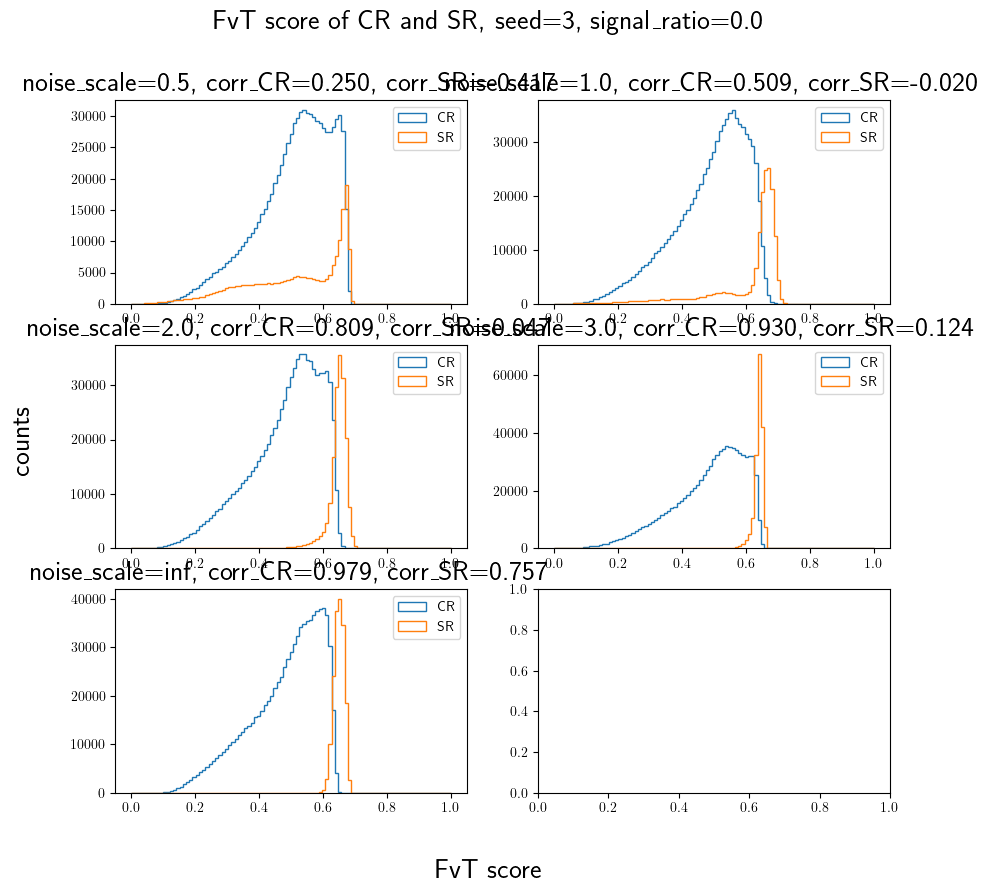

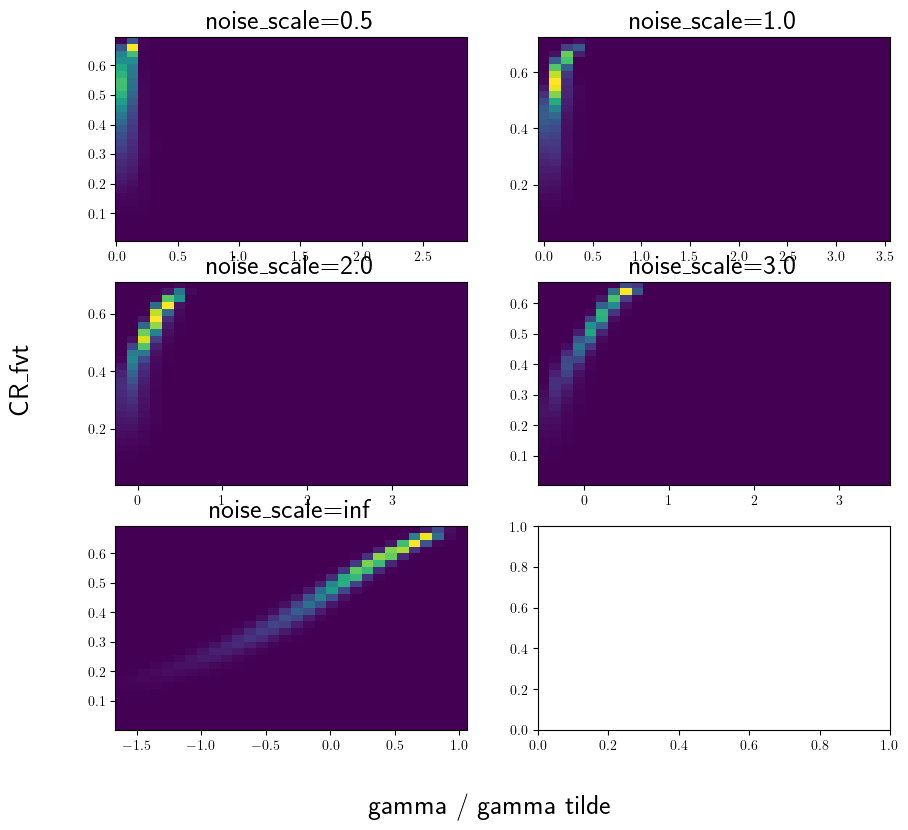

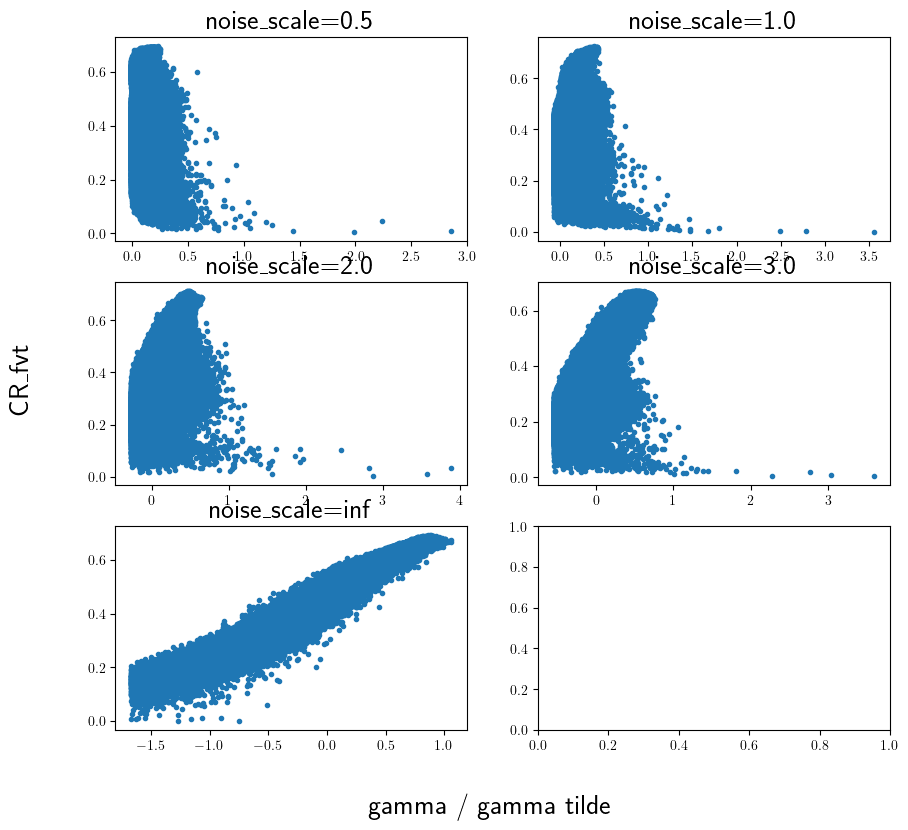

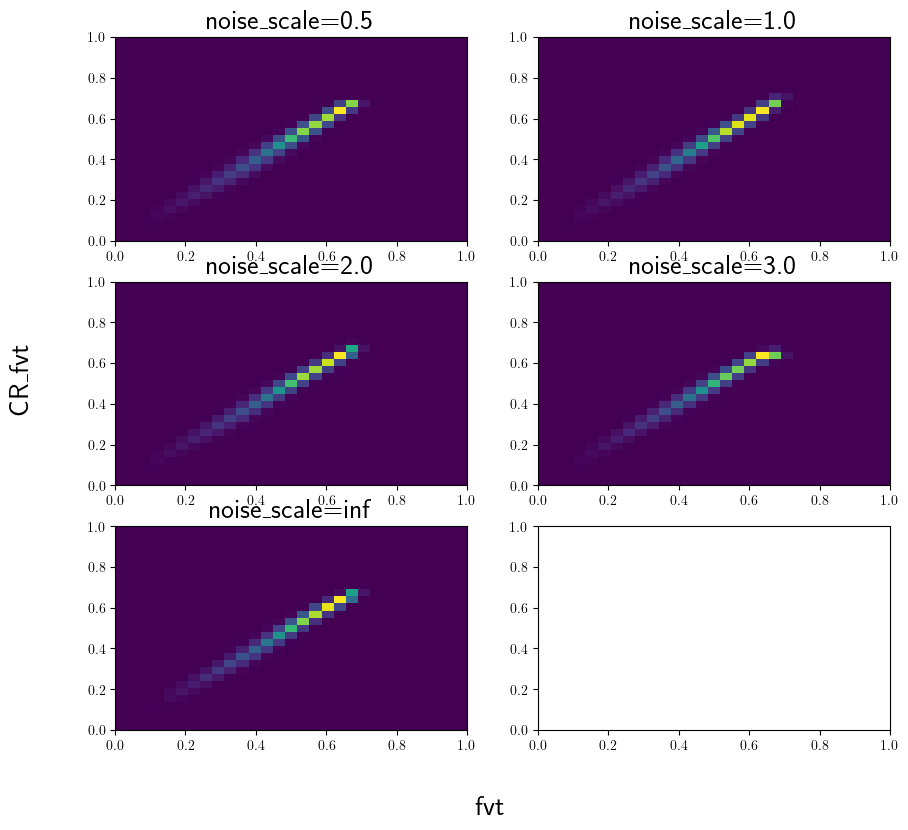

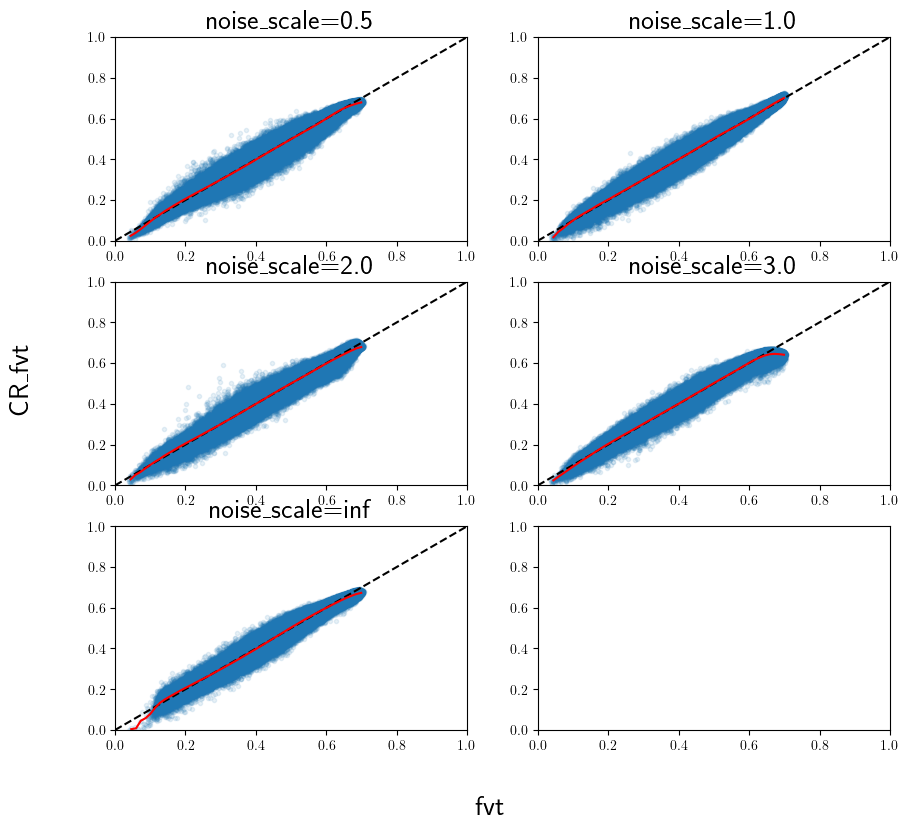

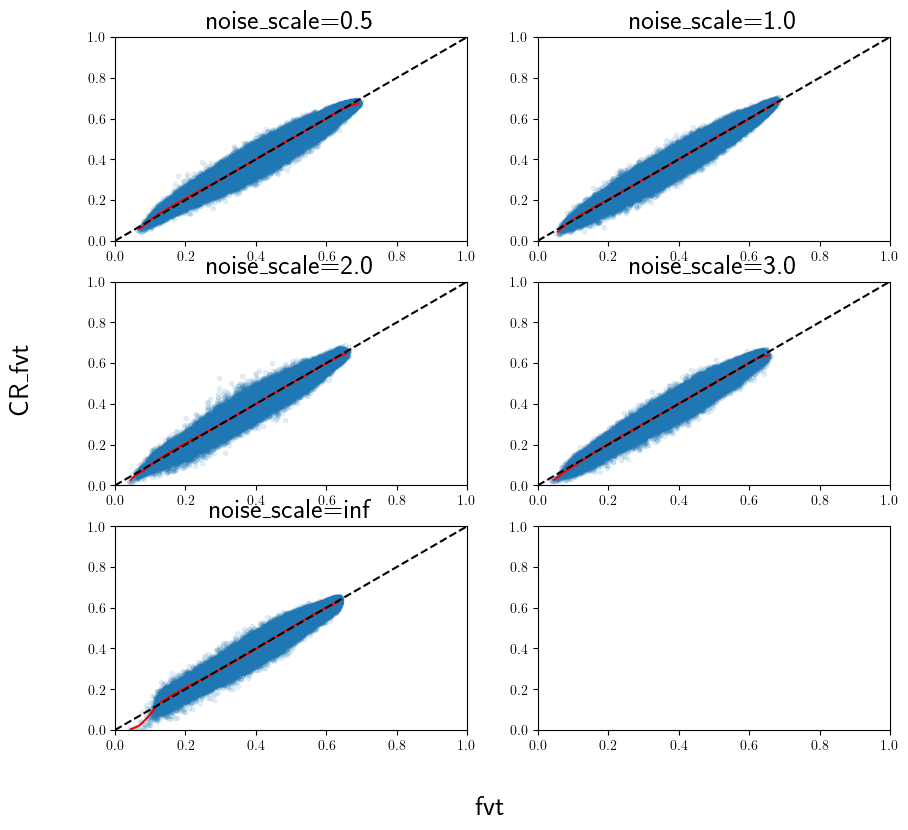

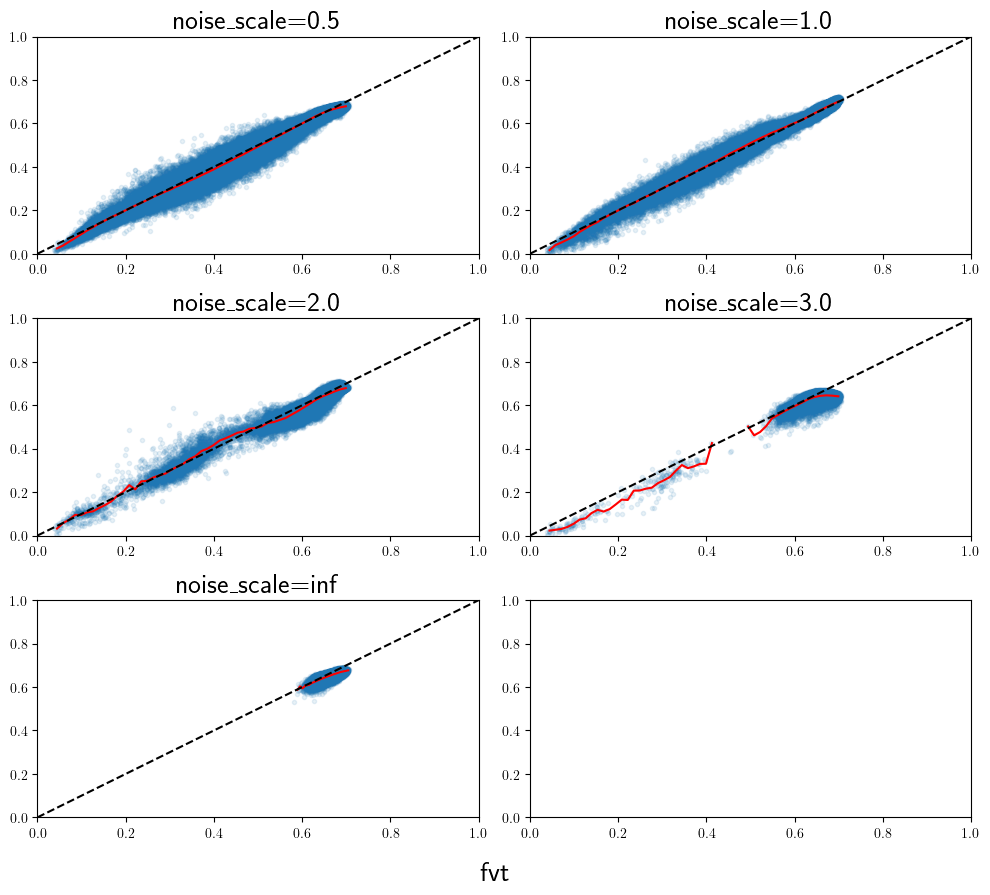

In [4]:
nbins = 10
signal_ratio = 0.0
signal_filename = "HH4b_picoAOD.h5"

for seed in [3]:
    hashes = TrainingInfo.find({"experiment_name": "CR_fvt_training_ensemble_max", 
                                    "dataset": lambda x: x["signal_ratio"] == signal_ratio and x["seed"] == seed, 
                                    "signal_region": lambda x: x["4b_in_SR"] == 0.2})

    noise_scales = []
    for hash_ in hashes:
        CR_fvt_tinfo = TrainingInfo.load(hash_)
        smeared_tinfo = TrainingInfo.load(CR_fvt_tinfo.hparams["signal_region"]["SR_stats_hashes"][0])
        if CR_fvt_tinfo.hparams["signal_region"]["stats_type"] == "smeared":
            noise_scale = smeared_tinfo.hparams["smearing"]["noise_scale"]
        else:
            noise_scale = np.inf
        noise_scales.append(noise_scale)
        
    # sort hashes by noise_scale 
    hashes = [x for _, x in sorted(zip(noise_scales, hashes), key=lambda pair: pair[0])]

    colors = plt.get_cmap("tab10")

    CR_fvt_tinfo = TrainingInfo.load(hashes[0])
    SR_stats_hashes = CR_fvt_tinfo.hparams["signal_region"]["SR_stats_hashes"]
    smeared_tinfo = TrainingInfo.load(SR_stats_hashes[0])
    msamples = MotherSamples.load(smeared_tinfo.ms_hash)
    events_train = events_from_scdinfo(
        msamples.scdinfo[smeared_tinfo.ms_idx], FEATURES, signal_filename
    )
    events_tst = events_from_scdinfo(
        msamples.scdinfo[~smeared_tinfo.ms_idx], FEATURES, signal_filename
    )

    base_fvt_scores_tst = []
    base_fvt_scores_train = []
    for hash_ in SR_stats_hashes:
        smeared_tinfo = TrainingInfo.load(hash_)
        base_tinfo = TrainingInfo.load(smeared_tinfo.hparams["encoder_hash"])
        base_fvt_logits_tst = base_tinfo.aux_info["base_fvt_logit_tst"]
        base_fvt_score_tst = np.exp(base_fvt_logits_tst) / (np.exp(base_fvt_logits_tst) + 1)
        base_fvt_scores_tst.append(base_fvt_score_tst)
        base_fvt_logits_train = base_tinfo.aux_info["base_fvt_logit_train"]
        base_fvt_score_train = np.exp(base_fvt_logits_train) / (np.exp(base_fvt_logits_train) + 1)
        base_fvt_scores_train.append(base_fvt_score_train)
        
    base_fvt_scores_tst = np.mean(base_fvt_scores_tst, axis=0)
    base_fvt_scores_train = np.mean(base_fvt_scores_train, axis=0)

    fig, axs = plt.subplots(nrows=3, ncols=2, figsize=(10, 9))
    fig.suptitle(f"FvT score of CR and SR, seed={seed}, signal_ratio={signal_ratio}")
    fig.supxlabel("FvT score")
    fig.supylabel("counts")

    fig_sr_fvt, axs_sr_fvt = plt.subplots(nrows=3, ncols=2, figsize=(10, 9))
    # fig_sr_fvt.suptitle(f"Histograms of SR and CR, seed={seed}, signal_ratio={signal_ratio}")
    fig_sr_fvt.supxlabel("gamma / gamma tilde")
    fig_sr_fvt.supylabel("CR_fvt")
    
    fig_sr_fvt_scatter, axs_sr_fvt_scatter = plt.subplots(nrows=3, ncols=2, figsize=(10, 9))
    # fig_sr_fvt.suptitle(f"Histograms of SR and CR, seed={seed}, signal_ratio={signal_ratio}")
    fig_sr_fvt_scatter.supxlabel("gamma / gamma tilde")
    fig_sr_fvt_scatter.supylabel("CR_fvt")
    
    fig_fvt_fvt, axs_fvt_fvt = plt.subplots(nrows=3, ncols=2, figsize=(10, 9))
    # fig_fvt_fvt.suptitle(f"Histograms of SR and CR, seed={seed}, signal_ratio={signal_ratio}")
    fig_fvt_fvt.supxlabel("fvt")
    fig_fvt_fvt.supylabel("CR_fvt")
    
    fig_fvt_fvt_scatter, axs_fvt_fvt_scatter = plt.subplots(nrows=3, ncols=2, figsize=(10, 9))
    # fig_fvt_fvt.suptitle(f"Histograms of SR and CR, seed={seed}, signal_ratio={signal_ratio}")
    fig_fvt_fvt_scatter.supxlabel("fvt")
    fig_fvt_fvt_scatter.supylabel("CR_fvt")

    fig_fvt_fvt_scatter_cr, axs_fvt_fvt_scatter_cr = plt.subplots(nrows=3, ncols=2, figsize=(10, 9))
    # fig_fvt_fvt.suptitle(f"Histograms of SR and CR, seed={seed}, signal_ratio={signal_ratio}")
    fig_fvt_fvt_scatter_cr.supxlabel("fvt")
    fig_fvt_fvt_scatter_cr.supylabel("CR_fvt")
    
    fig_fvt_fvt_scatter_sr, axs_fvt_fvt_scatter_sr = plt.subplots(nrows=3, ncols=2, figsize=(10, 9))
    # fig_fvt_fvt.suptitle(f"Histograms of SR and CR, seed={seed}, signal_ratio={signal_ratio}")
    fig_fvt_fvt_scatter_sr.supxlabel("fvt")
    fig_fvt_fvt_scatter_cr.supylabel("CR_fvt")


    for i, hash_ in enumerate(hashes):
        print("Done ", i)
        ax = axs.flatten()[i]
        ax_sr_fvt = axs_sr_fvt.flatten()[i]
        ax_sr_fvt_scatter = axs_sr_fvt_scatter.flatten()[i]
        ax_fvt_fvt = axs_fvt_fvt.flatten()[i]
        ax_fvt_fvt_scatter = axs_fvt_fvt_scatter.flatten()[i]
        ax_fvt_fvt_scatter_cr = axs_fvt_fvt_scatter_cr.flatten()[i]
        ax_fvt_fvt_scatter_sr = axs_fvt_fvt_scatter_sr.flatten()[i]
        CR_fvt_tinfo = TrainingInfo.load(hash_)
        SR_stats_hashes = CR_fvt_tinfo.hparams["signal_region"]["SR_stats_hashes"]
        smeared_tinfo = TrainingInfo.load(SR_stats_hashes[0])
        
        if CR_fvt_tinfo.hparams["signal_region"]["stats_type"] == "smeared":
            noise_scale = smeared_tinfo.hparams["smearing"]["noise_scale"]
        else:
            noise_scale = np.inf
        ensemble_mode = CR_fvt_tinfo.hparams["signal_region"]["ensemble_mode"]
        stats_type = CR_fvt_tinfo.hparams["signal_region"]["stats_type"]

        SR_stats_train, SR_stats_tst = compute_sr_stats(
            SR_stats_hashes,
            signal_filename,
            ensemble_mode,
            stats_type,
        )
        
        SR_cut, CR_cut = get_SR_CR_cut(
            SR_stats_train, events_train, CR_fvt_tinfo.hparams["signal_region"]
        )
        CR_idx = (SR_stats_tst >= CR_cut) & (SR_stats_tst < SR_cut)
        SR_idx = SR_stats_tst >= SR_cut
        
        events_tst_CR = events_tst[CR_idx]
        fvt_scores_tst_SR = CR_fvt_tinfo.aux_info["fvt_scores_tst_SR"]
        CR_fvt_model = CR_fvt_tinfo.load_trained_model("best")
        CR_fvt_model.eval()
        fvt_scores_tst_CR = CR_fvt_model.predict(events_tst_CR.X_torch)[:, 1].numpy()
        
        corr_CR = np.corrcoef(SR_stats_tst[CR_idx], fvt_scores_tst_CR)[0, 1]
        corr_SR = np.corrcoef(SR_stats_tst[SR_idx], fvt_scores_tst_SR)[0, 1]
        
        bins = np.linspace(0, 1, 100)
        ax.set_title(f"noise_scale={noise_scale}, corr_CR={corr_CR:.3f}, corr_SR={corr_SR:.3f}")
        ax.hist(fvt_scores_tst_CR, bins=bins, label="CR", histtype="step")
        ax.hist(fvt_scores_tst_SR, bins=bins, label="SR", histtype="step")
        ax.legend()
        
        ax_sr_fvt.set_title(f"noise_scale={noise_scale}")
        fvt_scores_all = np.concatenate([fvt_scores_tst_CR, fvt_scores_tst_SR])
        SR_stats_all = np.concatenate([SR_stats_tst[CR_idx], SR_stats_tst[SR_idx]])
        base_fvt_scores_all = np.concatenate([base_fvt_scores_tst[CR_idx], base_fvt_scores_tst[SR_idx]])
        
        ax_sr_fvt.set_title(f"noise_scale={noise_scale}")
        ax_sr_fvt.hist2d(SR_stats_all, fvt_scores_all, bins=(30, 30))

        ax_sr_fvt_scatter.set_title(f"noise_scale={noise_scale}")
        ax_sr_fvt_scatter.scatter(SR_stats_all, fvt_scores_all)
        
        ax_fvt_fvt.set_title(f"noise_scale={noise_scale}")
        bin_ = np.linspace(0, 1, 30)
        ax_fvt_fvt.hist2d(base_fvt_scores_all, fvt_scores_all, bins=(bin_, bin_))
        
        ax_fvt_fvt_scatter.set_title(f"noise_scale={noise_scale}")
        ax_fvt_fvt_scatter.scatter(base_fvt_scores_all, fvt_scores_all, alpha=0.1)
        ax_fvt_fvt_scatter.set_xlim(0, 1)   
        ax_fvt_fvt_scatter.set_ylim(0, 1)
        ax_fvt_fvt_scatter.plot([0, 1], [0, 1], color="black", linestyle="--")
        
        bins_tmp = np.linspace(np.min(base_fvt_scores_all), np.max(base_fvt_scores_all), 50)
        hist_fvt, _ = np.histogram(base_fvt_scores_all, bins_tmp)
        hist_CR_fvt_wgt, _ = np.histogram(base_fvt_scores_all, bins_tmp, weights=fvt_scores_all)
        midpoints = (bins_tmp[1:] + bins_tmp[:-1]) / 2
        
        ax_fvt_fvt_scatter.plot(midpoints, hist_CR_fvt_wgt / hist_fvt, color="red")
        
        bins_tmp_cr = np.linspace(np.min(base_fvt_scores_tst[CR_idx]), np.max(base_fvt_scores_tst[CR_idx]), 50)
        hist_fvt_cr, _ = np.histogram(base_fvt_scores_tst[CR_idx], bins=bins_tmp_cr)
        hist_CR_fvt_wgt_cr, _ = np.histogram(base_fvt_scores_tst[CR_idx], bins=bins_tmp_cr, weights=fvt_scores_tst_CR)
        midpoints_cr = (bins_tmp_cr[1:] + bins_tmp_cr[:-1]) / 2
        
        bins_tmp_sr = np.linspace(np.min(base_fvt_scores_tst[SR_idx]), np.max(base_fvt_scores_tst[SR_idx]), 50)
        hist_fvt_sr, _ = np.histogram(base_fvt_scores_tst[SR_idx], bins=bins_tmp_sr)
        hist_CR_fvt_wgt_sr, _ = np.histogram(base_fvt_scores_tst[SR_idx], bins=bins_tmp_sr, weights=fvt_scores_tst_SR)
        midpoints_sr = (bins_tmp_sr[1:] + bins_tmp_sr[:-1]) / 2
        
        ax_fvt_fvt_scatter_cr.plot(midpoints_cr, hist_CR_fvt_wgt_cr / hist_fvt_cr, color="red")
        ax_fvt_fvt_scatter_cr.set_title(f"noise_scale={noise_scale}")
        ax_fvt_fvt_scatter_cr.scatter(base_fvt_scores_tst[CR_idx], fvt_scores_tst_CR, alpha=0.1)
        ax_fvt_fvt_scatter_cr.set_xlim(0, 1)   
        ax_fvt_fvt_scatter_cr.set_ylim(0, 1)
        ax_fvt_fvt_scatter_cr.plot([0, 1], [0, 1], color="black", linestyle="--")
        
        ax_fvt_fvt_scatter_sr.plot(midpoints_sr, hist_CR_fvt_wgt_sr / hist_fvt_sr, color="red")
        ax_fvt_fvt_scatter_sr.set_title(f"noise_scale={noise_scale}")
        ax_fvt_fvt_scatter_sr.scatter(base_fvt_scores_tst[SR_idx], fvt_scores_tst_SR, alpha=0.1)
        ax_fvt_fvt_scatter_sr.set_xlim(0, 1)   
        ax_fvt_fvt_scatter_sr.set_ylim(0, 1)
        ax_fvt_fvt_scatter_sr.plot([0, 1], [0, 1], color="black", linestyle="--")
        
        
    plt.tight_layout()
    plt.show()

Processing hash 1/5
noise_scale = 0.5
Corr all: 0.036
Corr CR: 0.338
Corr SR: -0.281


/tmp/ipykernel_2221771/584037261.py:95: RuntimeWarning: invalid value encountered in divide
  return midpoints, hist_fvt_wgt / hist_fvt


Processing hash 2/5
noise_scale = 1.0
Corr all: 0.532
Corr CR: 0.651
Corr SR: -0.238
Processing hash 3/5
noise_scale = 2.0
Corr all: 0.862
Corr CR: 0.868
Corr SR: -0.161
Processing hash 4/5
noise_scale = 3.0
Corr all: 0.954
Corr CR: 0.947
Corr SR: 0.274
Processing hash 5/5
noise_scale = inf
Corr all: 0.981
Corr CR: 0.977
Corr SR: 0.382


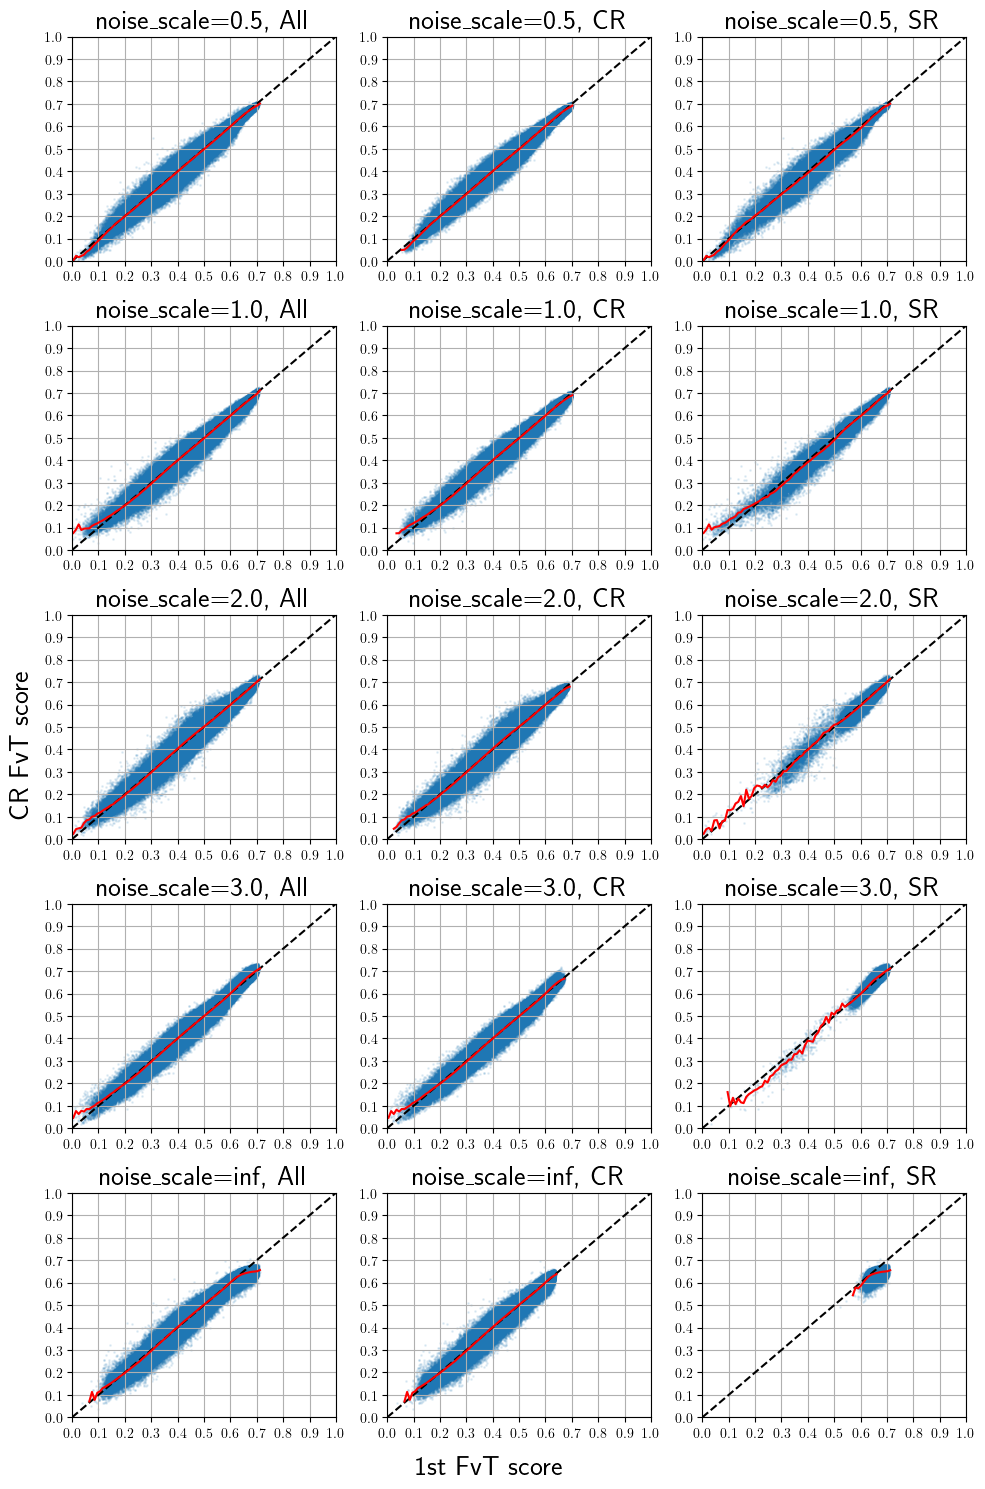

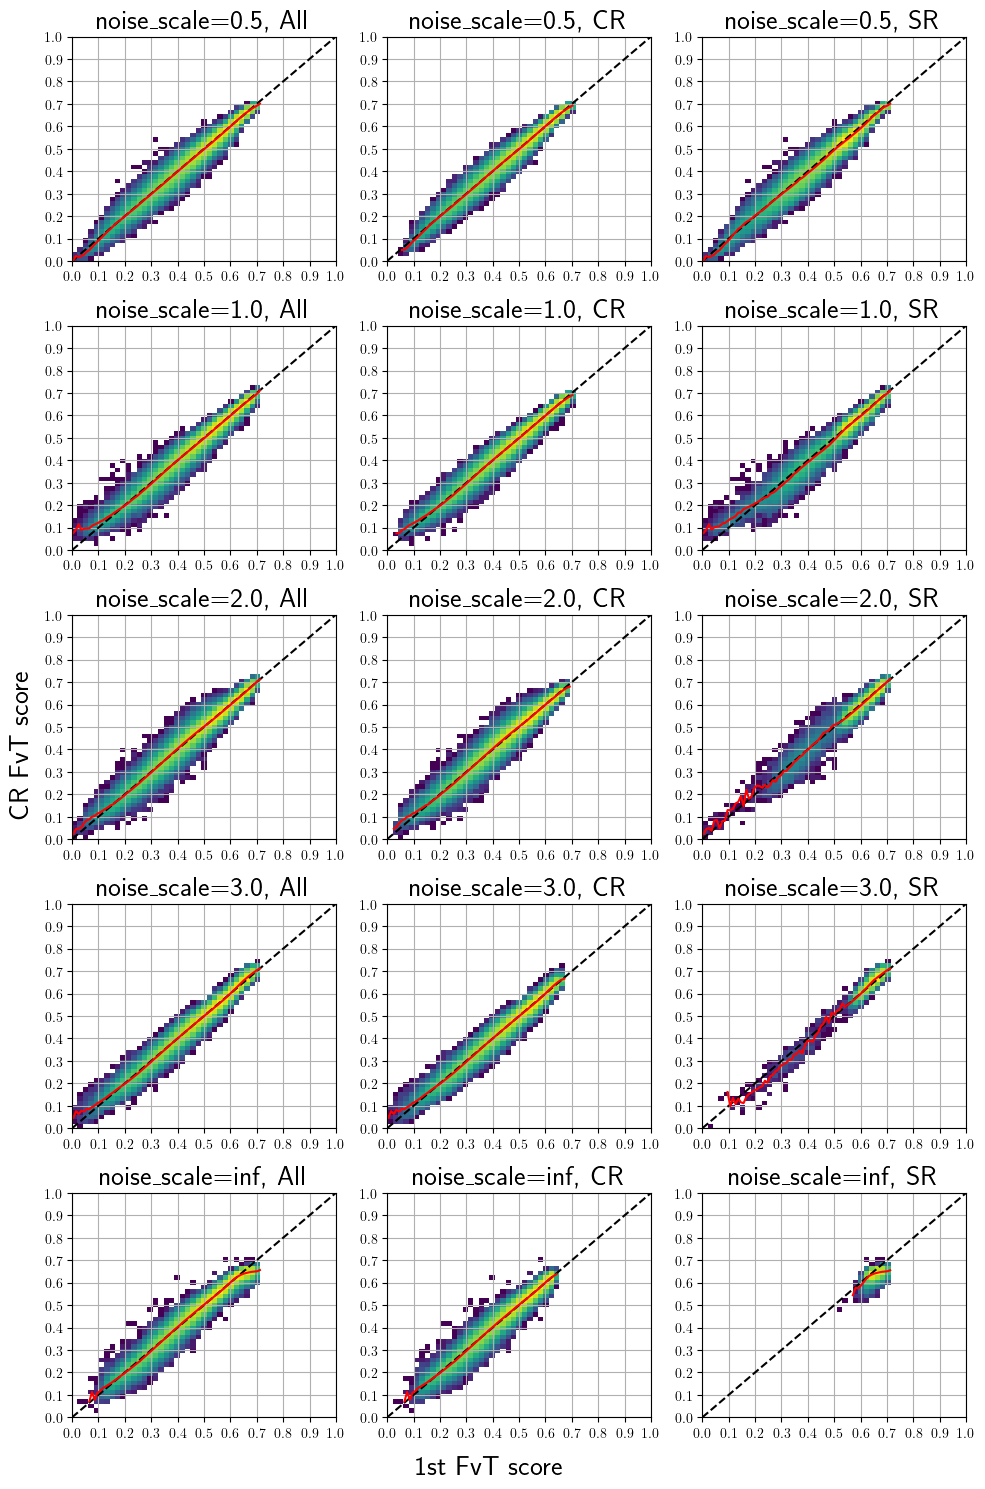

Processing hash 1/5
noise_scale = 0.5
Corr all: 0.063
Corr CR: 0.233
Corr SR: -0.171


/tmp/ipykernel_2221771/584037261.py:95: RuntimeWarning: invalid value encountered in divide
  return midpoints, hist_fvt_wgt / hist_fvt


Processing hash 2/5
noise_scale = 1.0
Corr all: 0.585
Corr CR: 0.681
Corr SR: -0.244
Processing hash 3/5
noise_scale = 2.0
Corr all: 0.893
Corr CR: 0.875
Corr SR: 0.010
Processing hash 4/5
noise_scale = 3.0
Corr all: 0.954
Corr CR: 0.944
Corr SR: 0.483
Processing hash 5/5
noise_scale = inf
Corr all: 0.984
Corr CR: 0.979
Corr SR: 0.552


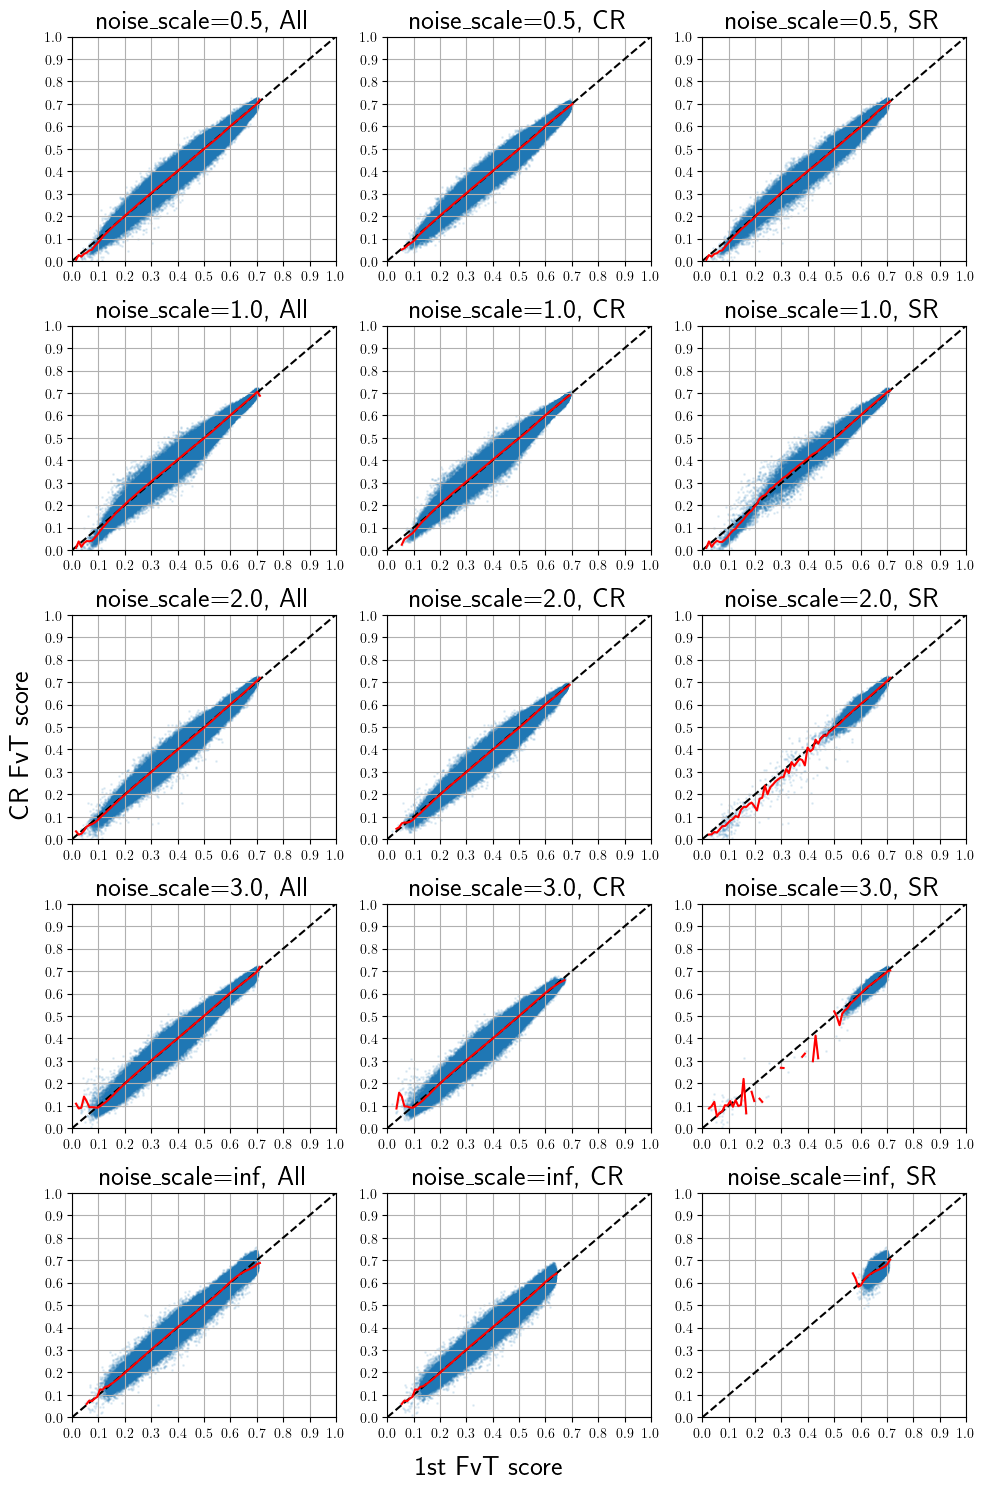

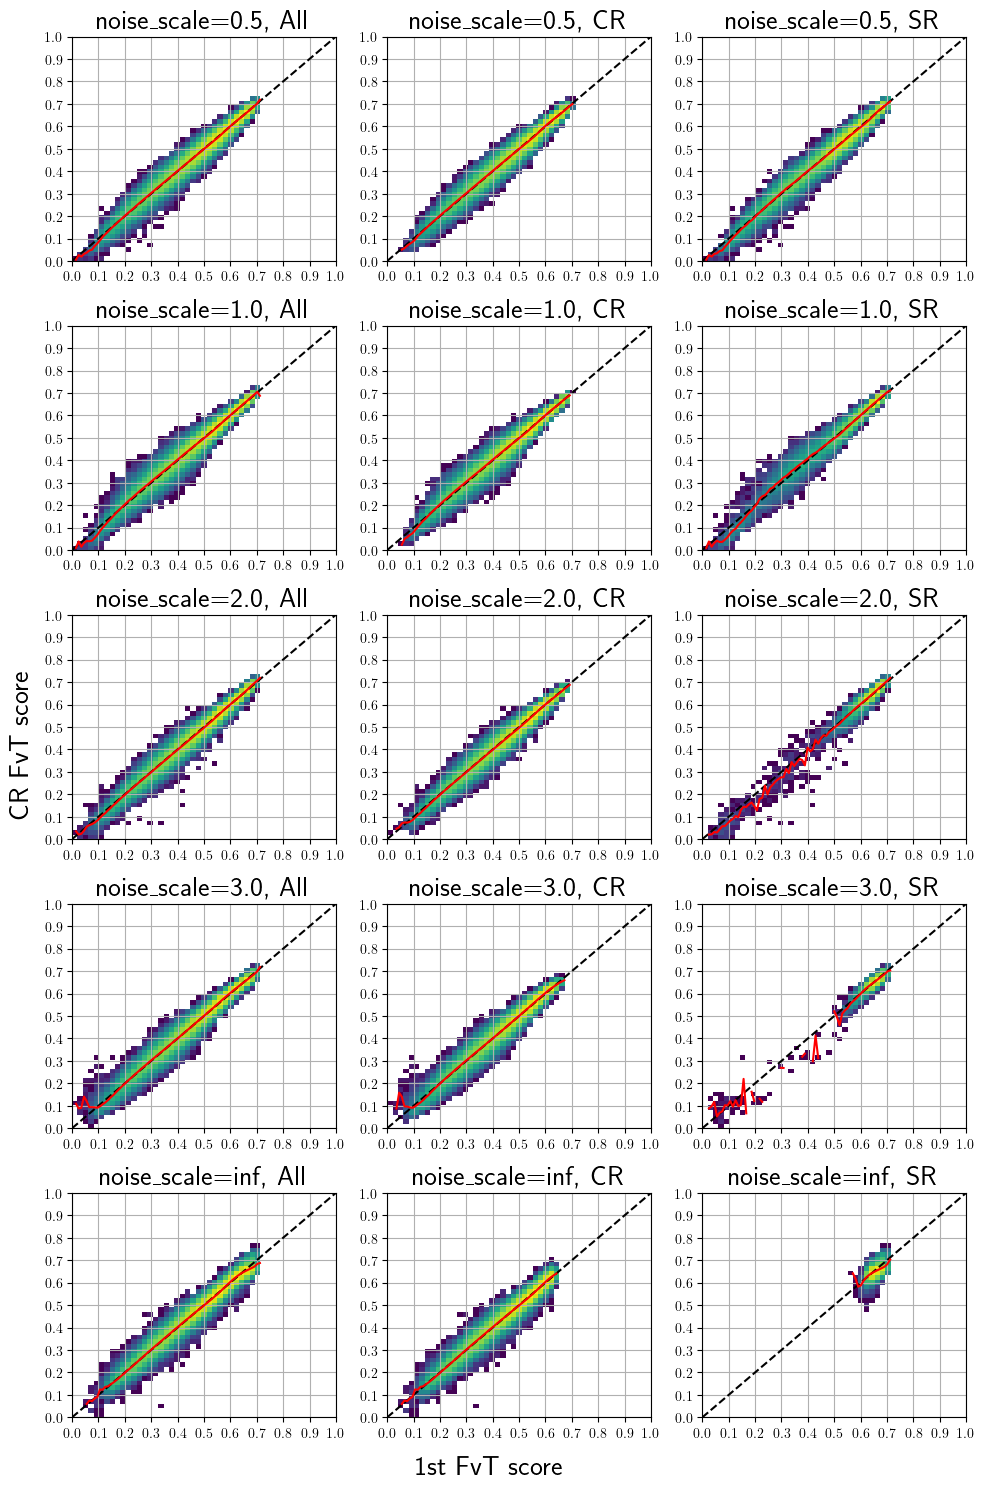

Processing hash 1/5
noise_scale = 0.5
Corr all: 0.225
Corr CR: 0.411
Corr SR: -0.302


/tmp/ipykernel_2221771/584037261.py:95: RuntimeWarning: invalid value encountered in divide
  return midpoints, hist_fvt_wgt / hist_fvt


Processing hash 2/5
noise_scale = 1.0
Corr all: 0.616
Corr CR: 0.652
Corr SR: -0.032
Processing hash 3/5
noise_scale = 2.0
Corr all: 0.887
Corr CR: 0.873
Corr SR: 0.073
Processing hash 4/5
noise_scale = 3.0
Corr all: 0.944
Corr CR: 0.945
Corr SR: 0.013
Processing hash 5/5
noise_scale = inf
Corr all: 0.984
Corr CR: 0.981
Corr SR: 0.411


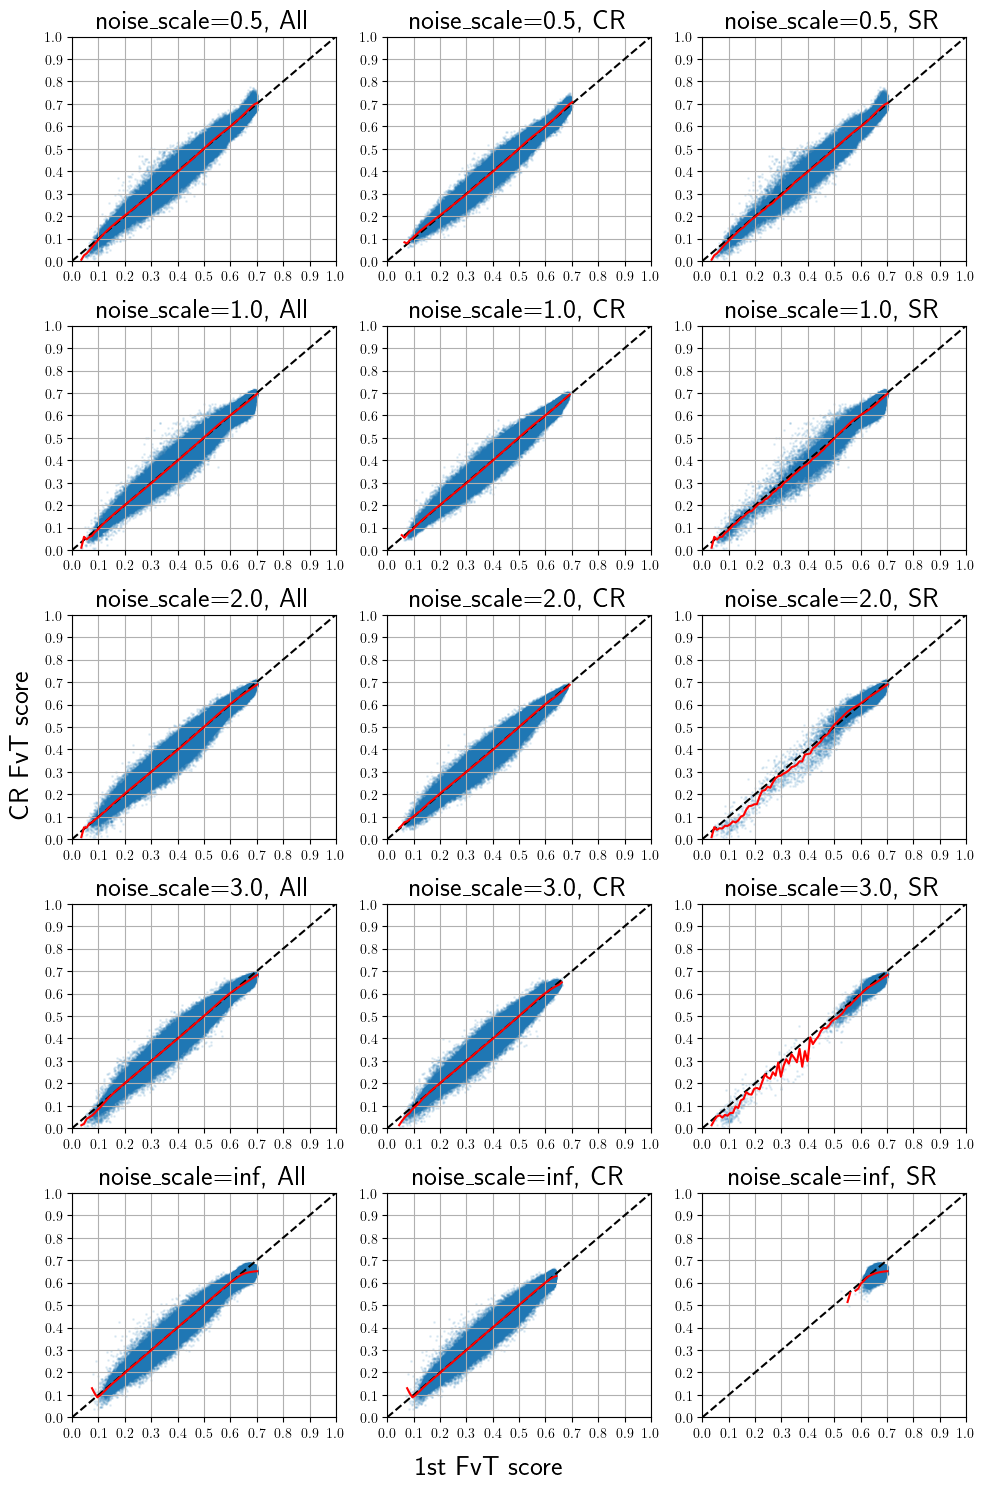

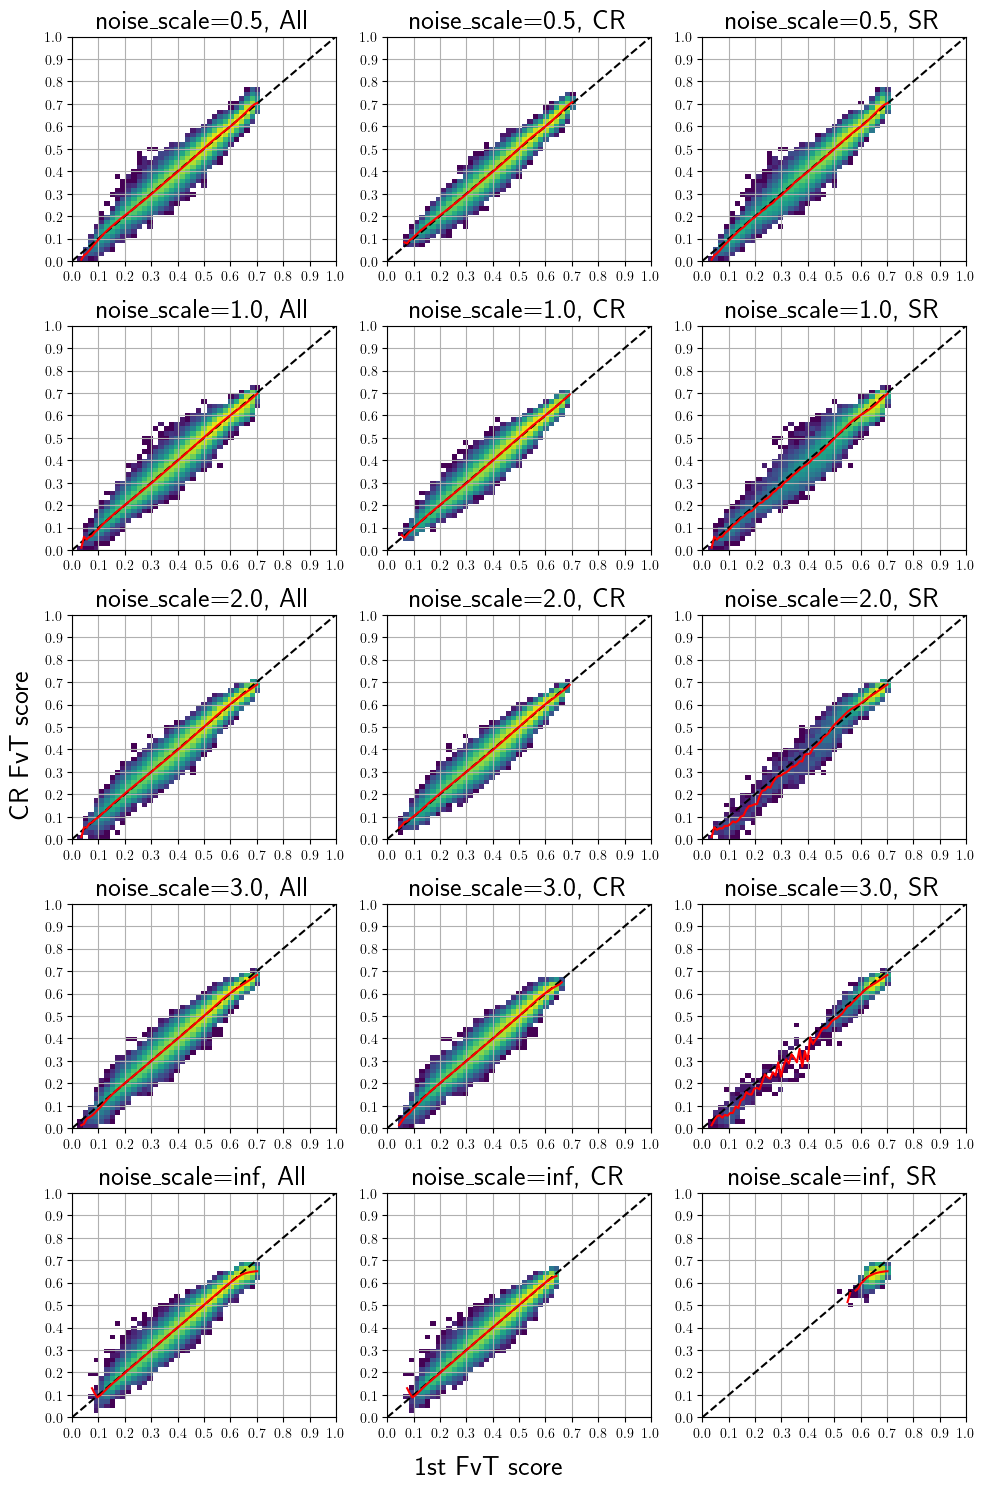

Processing hash 1/5
noise_scale = 0.5
Corr all: 0.038
Corr CR: 0.264
Corr SR: -0.275


/tmp/ipykernel_2221771/584037261.py:95: RuntimeWarning: invalid value encountered in divide
  return midpoints, hist_fvt_wgt / hist_fvt


Processing hash 2/5
noise_scale = 1.0
Corr all: 0.483
Corr CR: 0.590
Corr SR: -0.285
Processing hash 3/5
noise_scale = 2.0
Corr all: 0.840
Corr CR: 0.819
Corr SR: 0.001
Processing hash 4/5
noise_scale = 3.0
Corr all: 0.925
Corr CR: 0.916
Corr SR: 0.210
Processing hash 5/5
noise_scale = inf
Corr all: 0.986
Corr CR: 0.981
Corr SR: 0.744


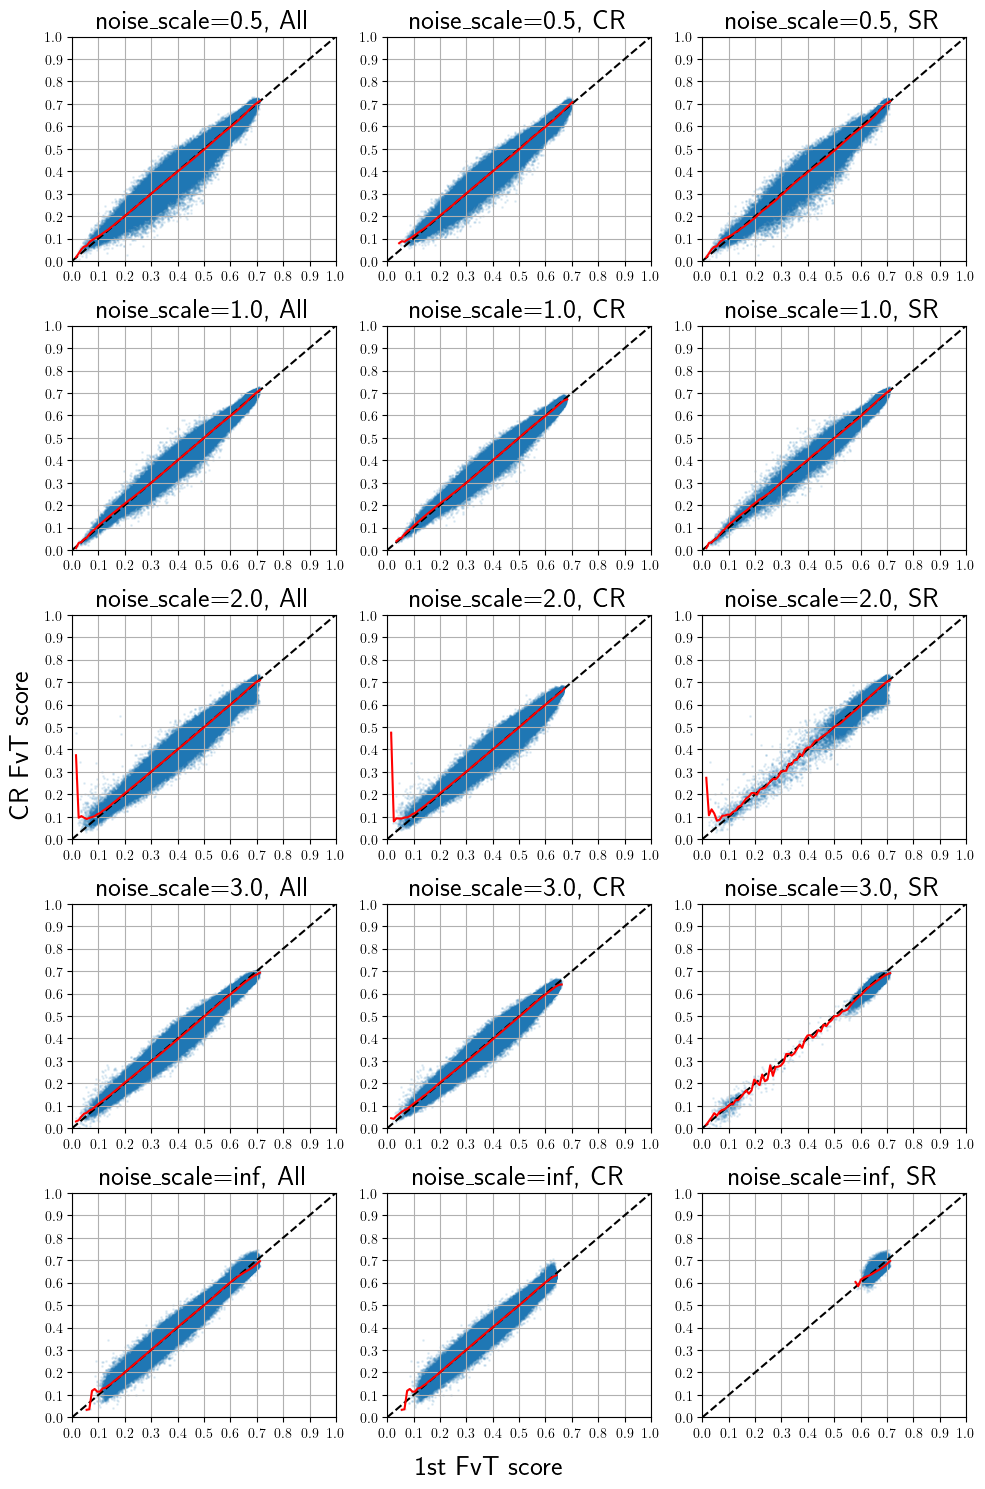

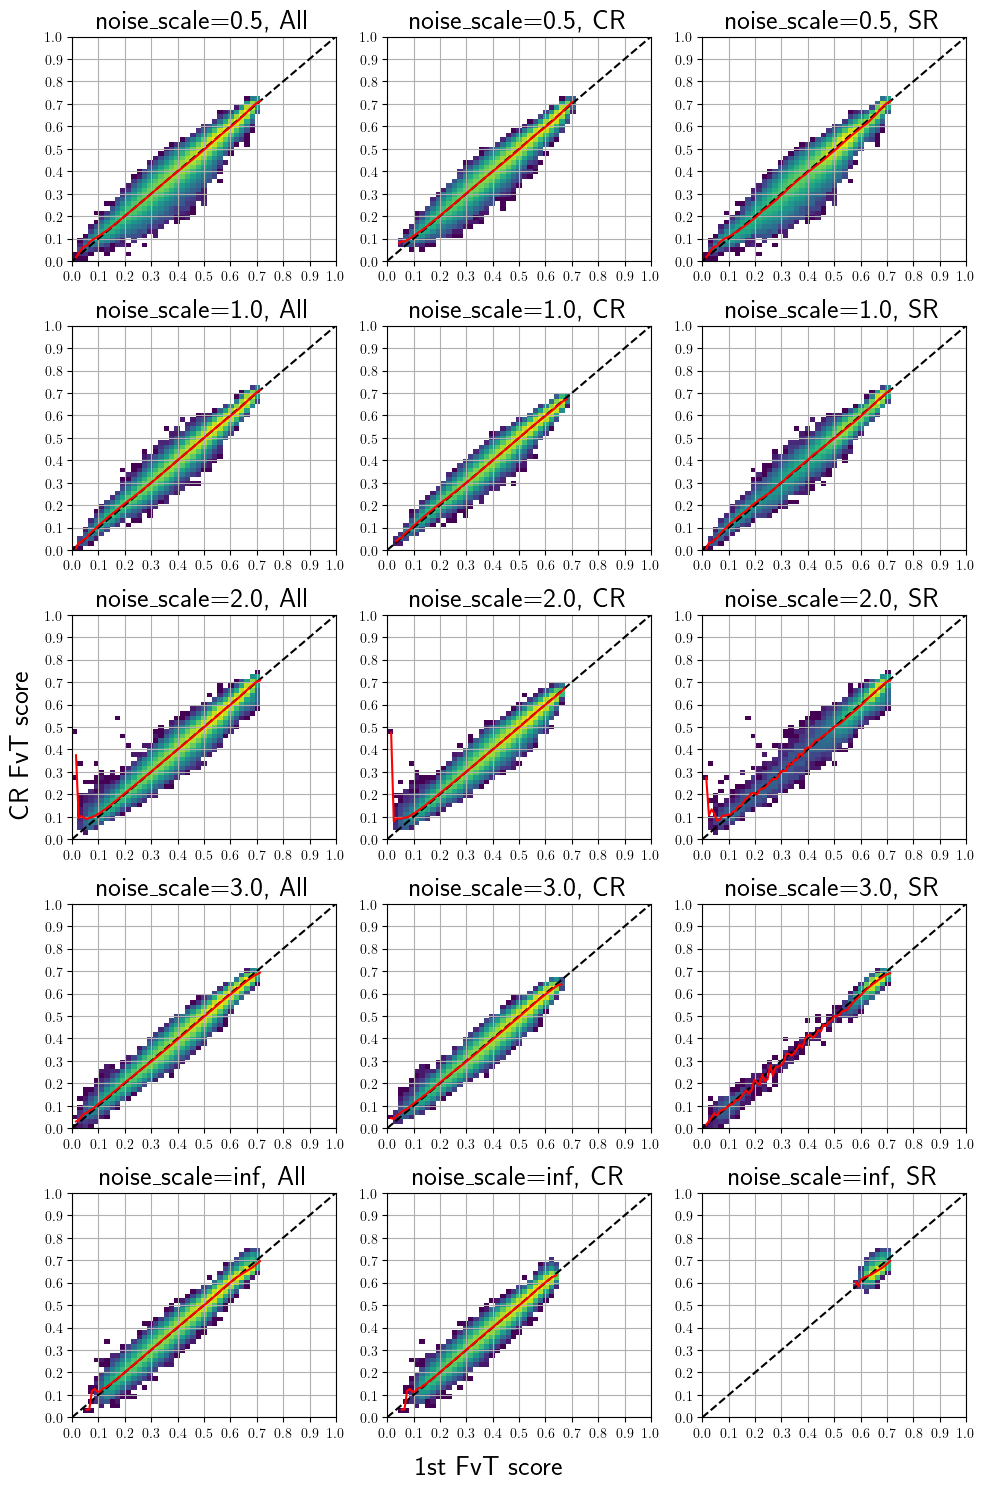

Processing hash 1/5
noise_scale = 0.5
Corr all: 0.210
Corr CR: 0.305
Corr SR: -0.098


/tmp/ipykernel_2221771/584037261.py:95: RuntimeWarning: invalid value encountered in divide
  return midpoints, hist_fvt_wgt / hist_fvt


Processing hash 2/5
noise_scale = 1.0
Corr all: 0.506
Corr CR: 0.625
Corr SR: -0.249
Processing hash 3/5
noise_scale = 2.0
Corr all: 0.844
Corr CR: 0.828
Corr SR: -0.133
Processing hash 4/5
noise_scale = 3.0
Corr all: 0.937
Corr CR: 0.926
Corr SR: 0.184
Processing hash 5/5
noise_scale = inf
Corr all: 0.985
Corr CR: 0.980
Corr SR: 0.658


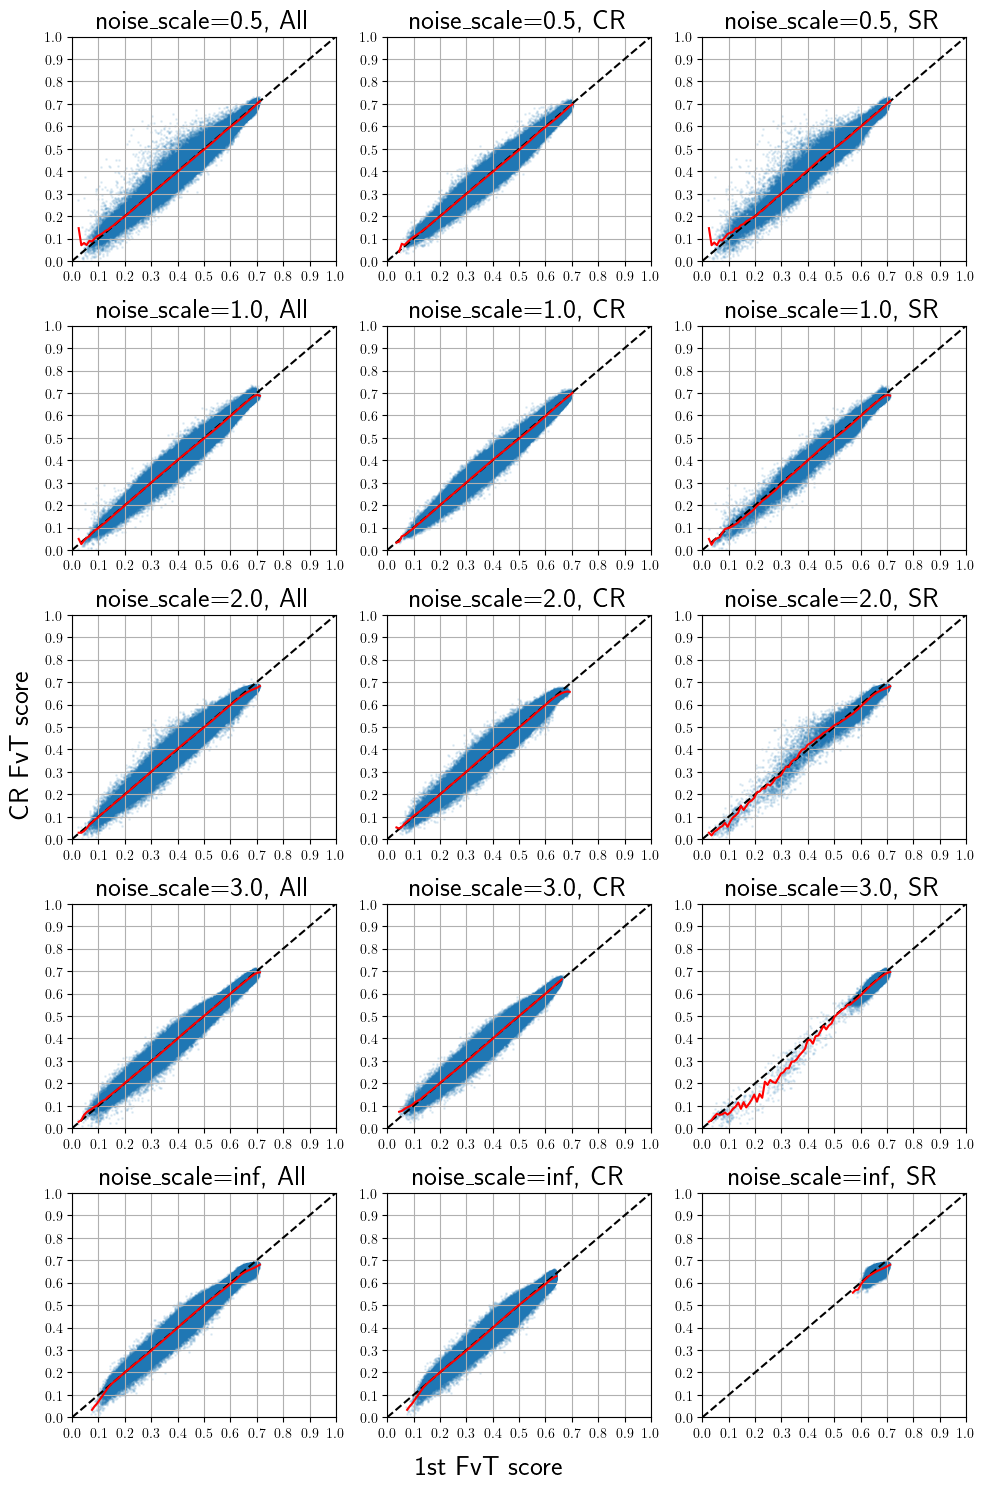

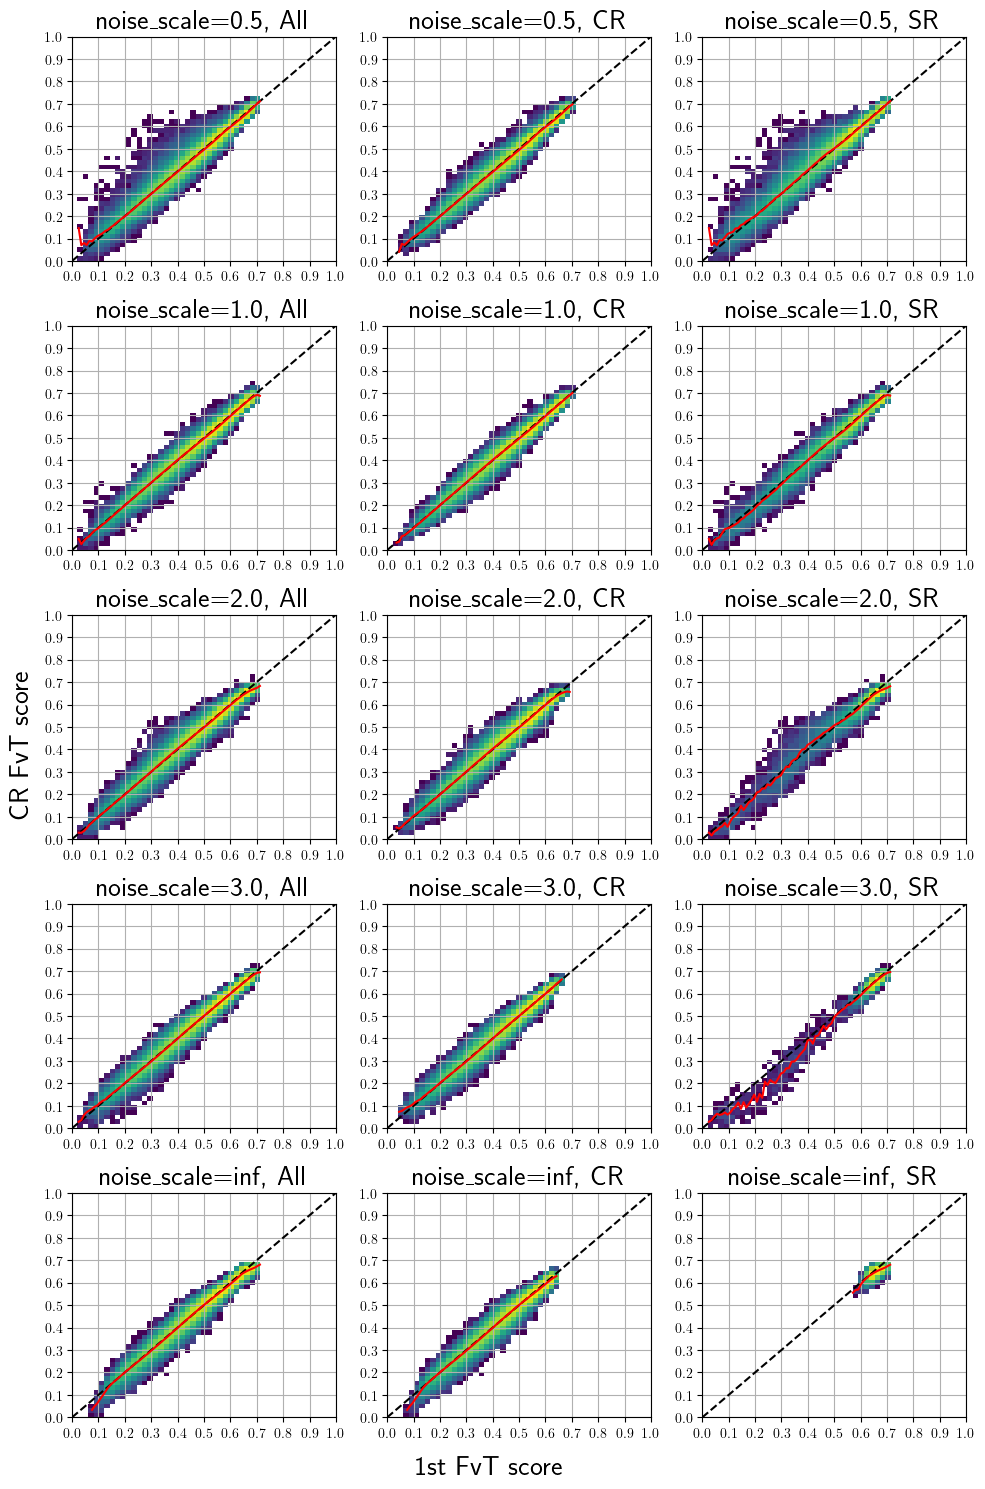

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from typing import List, Tuple, Dict, Any, Optional
from matplotlib.colors import LogNorm

# Constants
NBINS = 10
SIGNAL_RATIO = 0.0
SIGNAL_FILENAME = "HH4b_picoAOD.h5"

def load_training_info(experiment_name: str, signal_ratio: float, seed: int) -> List[str]:
    """Find training info hashes based on experiment parameters."""
    return TrainingInfo.find({
        "experiment_name": experiment_name, 
        "dataset": lambda x: x["signal_ratio"] == signal_ratio and x["seed"] == seed, 
        "signal_region": lambda x: x["4b_in_SR"] == 0.2
    })

def get_noise_scales(hashes: List[str]) -> List[float]:
    """Extract noise scales from training info hashes."""
    noise_scales = []
    for hash_ in hashes:
        CR_fvt_tinfo = TrainingInfo.load(hash_)
        smeared_tinfo = TrainingInfo.load(CR_fvt_tinfo.hparams["signal_region"]["SR_stats_hashes"][0])
        if CR_fvt_tinfo.hparams["signal_region"]["stats_type"] == "smeared":
            noise_scale = smeared_tinfo.hparams["smearing"]["noise_scale"]
        else:
            noise_scale = np.inf
        noise_scales.append(noise_scale)
    return noise_scales

def sort_hashes_by_noise_scale(hashes: List[str], noise_scales: List[float]) -> List[str]:
    """Sort hashes by their corresponding noise scales."""
    return [x for _, x in sorted(zip(noise_scales, hashes), key=lambda pair: pair[0])]

def load_events_data(hash_: str) -> Tuple[Any, Any]:
    """Load training and test events data from a hash."""
    CR_fvt_tinfo = TrainingInfo.load(hash_)
    SR_stats_hashes = CR_fvt_tinfo.hparams["signal_region"]["SR_stats_hashes"]
    smeared_tinfo = TrainingInfo.load(SR_stats_hashes[0])
    msamples = MotherSamples.load(smeared_tinfo.ms_hash)
    
    events_train = events_from_scdinfo(
        msamples.scdinfo[smeared_tinfo.ms_idx], 
        FEATURES, 
        SIGNAL_FILENAME
    )
    events_tst = events_from_scdinfo(
        msamples.scdinfo[~smeared_tinfo.ms_idx], 
        FEATURES, 
        SIGNAL_FILENAME
    )
    return events_train, events_tst

def calculate_base_fvt_scores(SR_stats_hashes: List[str]) -> Tuple[np.ndarray, np.ndarray]:
    """Calculate base FvT scores for training and test sets."""
    base_fvt_scores_tst = []
    base_fvt_scores_train = []
    
    for hash_ in SR_stats_hashes:
        smeared_tinfo = TrainingInfo.load(hash_)
        base_tinfo = TrainingInfo.load(smeared_tinfo.hparams["encoder_hash"])
        
        # Test scores
        base_fvt_logits_tst = base_tinfo.aux_info["base_fvt_logit_tst"]
        base_fvt_score_tst = np.exp(base_fvt_logits_tst) / (np.exp(base_fvt_logits_tst) + 1)
        base_fvt_scores_tst.append(base_fvt_score_tst)
        
        # Training scores
        base_fvt_logits_train = base_tinfo.aux_info["base_fvt_logit_train"]
        base_fvt_score_train = np.exp(base_fvt_logits_train) / (np.exp(base_fvt_logits_train) + 1)
        base_fvt_scores_train.append(base_fvt_score_train)
    
    return np.mean(base_fvt_scores_tst, axis=0), np.mean(base_fvt_scores_train, axis=0)

def create_figure_with_subplots(rows: int = 3, cols: int = 2, figsize: Tuple[int, int] = (10, 9), 
                              title: Optional[str] = None, 
                              xlabel: Optional[str] = None, 
                              ylabel: Optional[str] = None) -> Tuple[plt.Figure, np.ndarray]:
    """Create a figure with subplots and common labels."""
    fig, axs = plt.subplots(nrows=rows, ncols=cols, figsize=figsize)
    if title:
        fig.suptitle(title)
    if xlabel:
        fig.supxlabel(xlabel)
    if ylabel:
        fig.supylabel(ylabel)
    return fig, axs

def compute_avg_fvt_score(base_fvt_scores: np.ndarray, fvt_scores: np.ndarray) -> np.ndarray:
    bins = np.linspace(0, 1, 100)
    hist_fvt, _ = np.histogram(base_fvt_scores, bins)
    hist_fvt_wgt, _ = np.histogram(base_fvt_scores, bins, weights=fvt_scores)
    midpoints = (bins[1:] + bins[:-1]) / 2
    return midpoints, hist_fvt_wgt / hist_fvt

def scatter_fvt_fvt(ax: plt.Axes, base_fvt_scores: np.ndarray, fvt_scores: np.ndarray, 
                 fvt_avg: np.ndarray, midpoints: np.ndarray):
    # enable grid
    # set x and y ticks to 0.1, 0.2, ..., 1
    ax.set_xticks(np.arange(0, 1.1, 0.1))
    ax.set_yticks(np.arange(0, 1.1, 0.1))
    ax.grid(True)
    ax.plot([0, 1], [0, 1], color="black", linestyle="--")
    ax.scatter(base_fvt_scores, fvt_scores, alpha=0.1, s=1)
    ax.plot(midpoints, fvt_avg, color="red")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    
def hist_fvt_fvt(ax: plt.Axes, base_fvt_scores: np.ndarray, fvt_scores: np.ndarray, 
                 fvt_avg: np.ndarray, midpoints: np.ndarray):
    ax.set_xticks(np.arange(0, 1.1, 0.1))
    ax.set_yticks(np.arange(0, 1.1, 0.1))
    ax.grid(True)
    bins = np.linspace(0, 1, 50)
    ax.plot([0, 1], [0, 1], color="black", linestyle="--")
    ax.hist2d(base_fvt_scores, fvt_scores, bins=(bins, bins), 
              norm=LogNorm())
    ax.plot(midpoints, fvt_avg, color="red")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    
def plot_hash_results(hash_: str, 
                    base_fvt_scores_tst: np.ndarray, 
                    events_tst: Any, 
                    axs_scatter: plt.Axes, 
                    axs_hist: plt.Axes, 
                    plot_idx: int):
    """Analyze and plot results for a specific hash."""
    CR_fvt_tinfo = TrainingInfo.load(hash_)
    SR_stats_hashes = CR_fvt_tinfo.hparams["signal_region"]["SR_stats_hashes"]
    smeared_tinfo = TrainingInfo.load(SR_stats_hashes[0])
    
    # Get noise scale
    if CR_fvt_tinfo.hparams["signal_region"]["stats_type"] == "smeared":
        noise_scale = smeared_tinfo.hparams["smearing"]["noise_scale"]
    else:
        noise_scale = np.inf
    
    ensemble_mode = CR_fvt_tinfo.hparams["signal_region"]["ensemble_mode"]
    stats_type = CR_fvt_tinfo.hparams["signal_region"]["stats_type"]

    # Compute statistics
    SR_stats_train, SR_stats_tst = compute_sr_stats(
        SR_stats_hashes,
        SIGNAL_FILENAME,
        ensemble_mode,
        stats_type,
    )
    
    # Get region cuts and indices
    SR_cut, CR_cut = get_SR_CR_cut(
        SR_stats_train, events_train, CR_fvt_tinfo.hparams["signal_region"]
    )
    CR_idx = (SR_stats_tst >= CR_cut) & (SR_stats_tst < SR_cut)
    SR_idx = SR_stats_tst >= SR_cut
    
    # Calculate FVT scores
    events_tst_CR = events_tst[CR_idx]
    fvt_scores_tst_SR = CR_fvt_tinfo.aux_info["fvt_scores_tst_SR"]
    CR_fvt_model = CR_fvt_tinfo.load_trained_model("best")
    CR_fvt_model.eval()
    fvt_scores_tst_CR = CR_fvt_model.predict(events_tst_CR.X_torch)[:, 1].numpy()
    
    # Calculate correlations
    corr_CR = np.corrcoef(SR_stats_tst[CR_idx], fvt_scores_tst_CR)[0, 1]
    corr_SR = np.corrcoef(SR_stats_tst[SR_idx], fvt_scores_tst_SR)[0, 1]
    fvt_scores_all = np.zeros_like(SR_stats_tst)
    fvt_scores_all[CR_idx] = fvt_scores_tst_CR
    fvt_scores_all[SR_idx] = fvt_scores_tst_SR
    corr_all = np.corrcoef(SR_stats_tst, fvt_scores_all)[0, 1]
    
    print(f"noise_scale = {noise_scale}")
    print(f"Corr all: {corr_all:.3f}")
    print(f"Corr CR: {corr_CR:.3f}")
    print(f"Corr SR: {corr_SR:.3f}")
    
    # Combine data for plots
    fvt_scores_all = np.concatenate([fvt_scores_tst_CR, fvt_scores_tst_SR])
    base_fvt_scores_all = np.concatenate([base_fvt_scores_tst[CR_idx], base_fvt_scores_tst[SR_idx]])
    
    midpoints, fvt_avg = compute_avg_fvt_score(base_fvt_scores_all, fvt_scores_all)
    midpoints_cr, fvt_avg_cr = compute_avg_fvt_score(base_fvt_scores_tst[CR_idx], fvt_scores_tst_CR)
    midpoints_sr, fvt_avg_sr = compute_avg_fvt_score(base_fvt_scores_tst[SR_idx], fvt_scores_tst_SR)
    
    axs_scatter[plot_idx, 0].set_title(f"noise_scale={noise_scale}, All")
    scatter_fvt_fvt(axs_scatter[plot_idx, 0], base_fvt_scores_all, fvt_scores_all, fvt_avg, midpoints)
    
    axs_scatter[plot_idx, 1].set_title(f"noise_scale={noise_scale}, CR")
    scatter_fvt_fvt(axs_scatter[plot_idx, 1], base_fvt_scores_tst[CR_idx], fvt_scores_tst_CR, fvt_avg_cr, midpoints_cr)
    
    axs_scatter[plot_idx, 2].set_title(f"noise_scale={noise_scale}, SR")
    scatter_fvt_fvt(axs_scatter[plot_idx, 2], base_fvt_scores_tst[SR_idx], fvt_scores_tst_SR, fvt_avg_sr, midpoints_sr)
    
    axs_hist[plot_idx, 0].set_title(f"noise_scale={noise_scale}, All")
    hist_fvt_fvt(axs_hist[plot_idx, 0], base_fvt_scores_all, fvt_scores_all, fvt_avg, midpoints)
    
    axs_hist[plot_idx, 1].set_title(f"noise_scale={noise_scale}, CR")
    hist_fvt_fvt(axs_hist[plot_idx, 1], base_fvt_scores_tst[CR_idx], fvt_scores_tst_CR, fvt_avg_cr, midpoints_cr)
    
    axs_hist[plot_idx, 2].set_title(f"noise_scale={noise_scale}, SR")
    hist_fvt_fvt(axs_hist[plot_idx, 2], base_fvt_scores_tst[SR_idx], fvt_scores_tst_SR, fvt_avg_sr, midpoints_sr)


for seed in [5, 10, 15, 20, 25]:
    # Find and sort hashes
    hashes = load_training_info("CR_fvt_training_ensemble_max", SIGNAL_RATIO, seed)
    noise_scales = get_noise_scales(hashes)
    hashes = sort_hashes_by_noise_scale(hashes, noise_scales)
    
    # Load initial data
    CR_fvt_tinfo = TrainingInfo.load(hashes[0])
    events_train, events_tst = load_events_data(hashes[0])
    
    # Get base FVT scores
    SR_stats_hashes = CR_fvt_tinfo.hparams["signal_region"]["SR_stats_hashes"]
    base_fvt_scores_tst, base_fvt_scores_train = calculate_base_fvt_scores(SR_stats_hashes)

    fig_scatter, axs_scatter = plt.subplots(5, 3, figsize=(10, 15))
    fig_scatter.supxlabel("1st FvT score")
    fig_scatter.supylabel("CR FvT score")
    fig_hist, axs_hist = plt.subplots(5, 3, figsize=(10, 15))
    fig_hist.supxlabel("1st FvT score")
    fig_hist.supylabel("CR FvT score")
    
    # Process each hash
    for i, hash_ in enumerate(hashes):
        print(f"Processing hash {i+1}/{len(hashes)}")
        plot_hash_results(hash_, base_fvt_scores_tst, events_tst, axs_scatter, axs_hist, i)
    
    # Display results
    for fig in [fig_scatter, fig_hist]: 
        fig.tight_layout()
    plt.show()

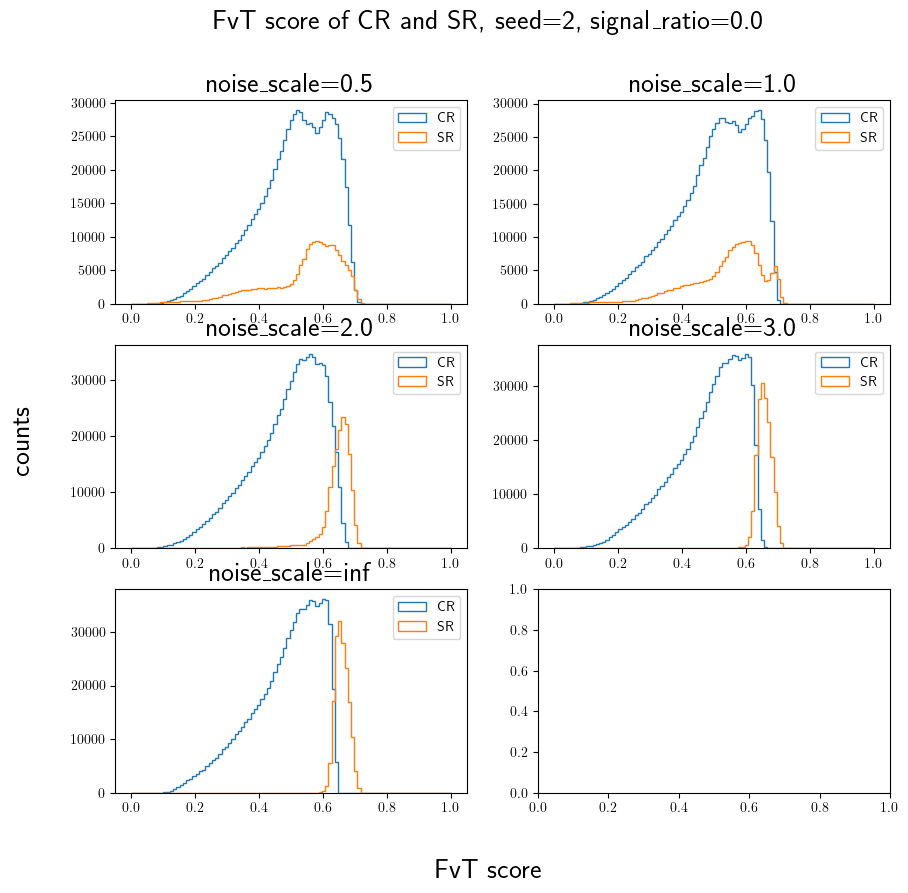

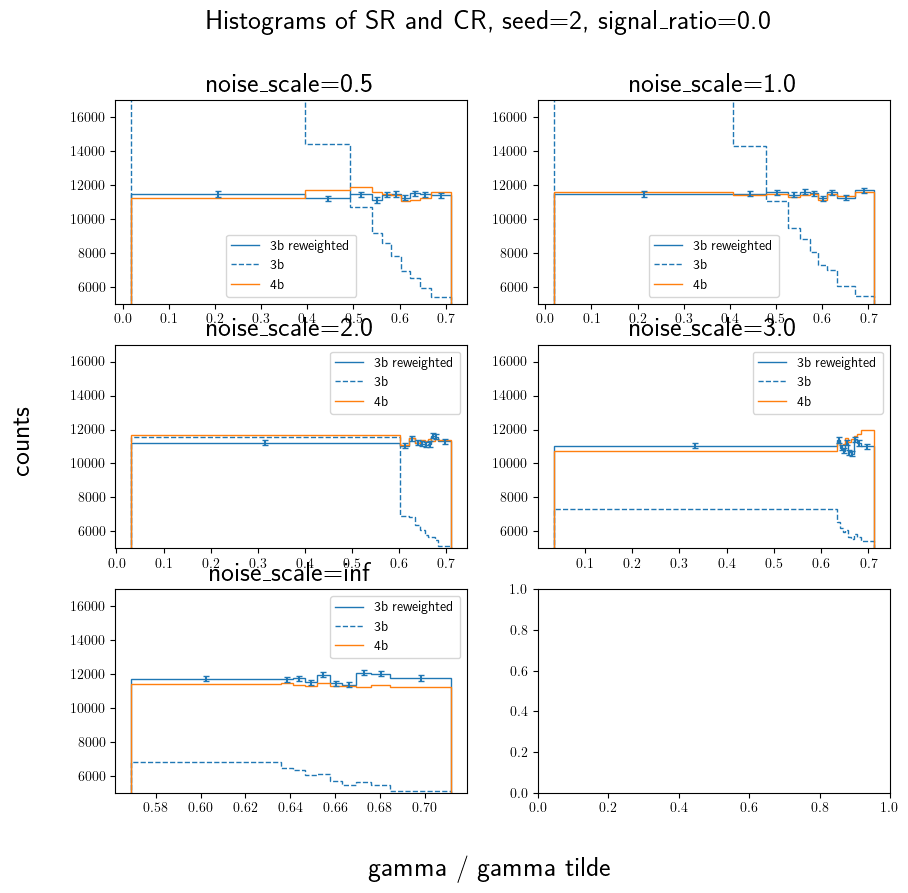

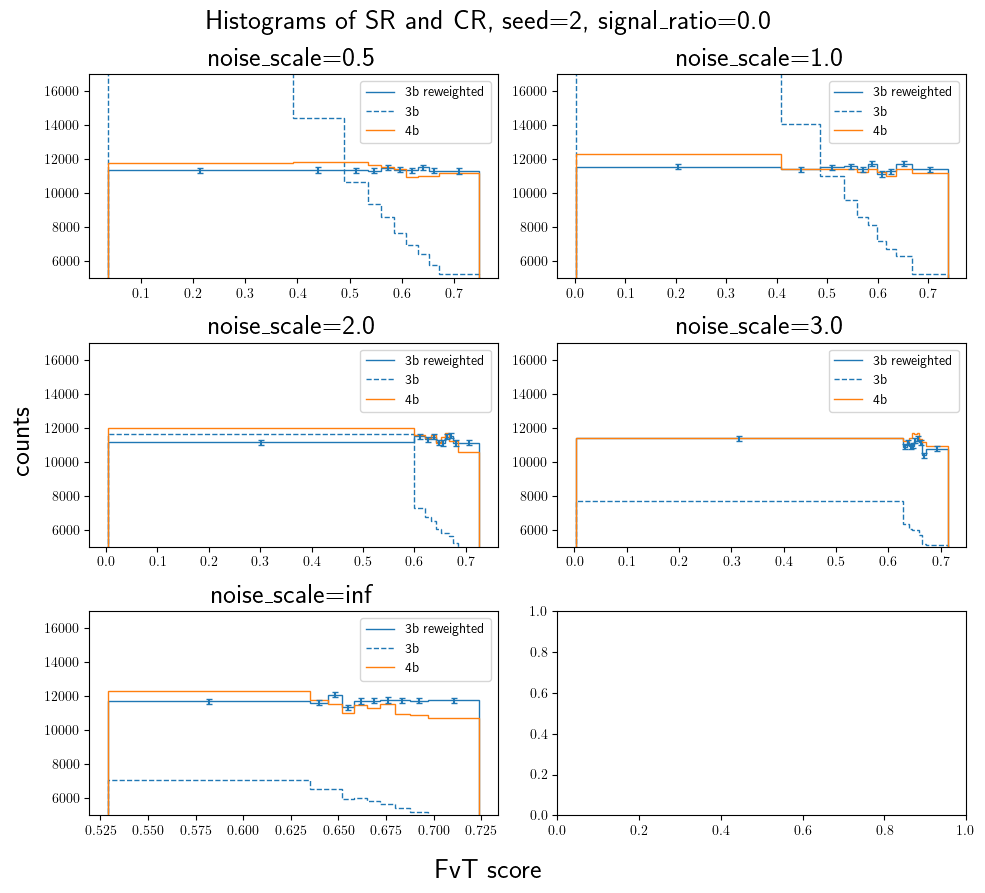

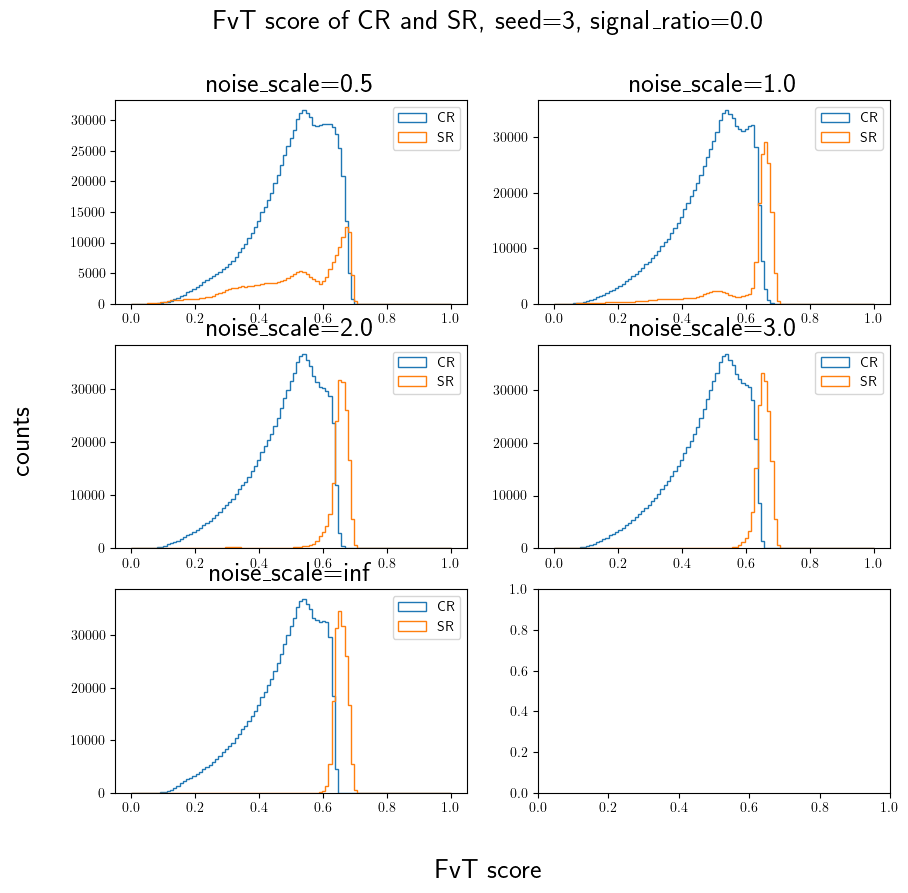

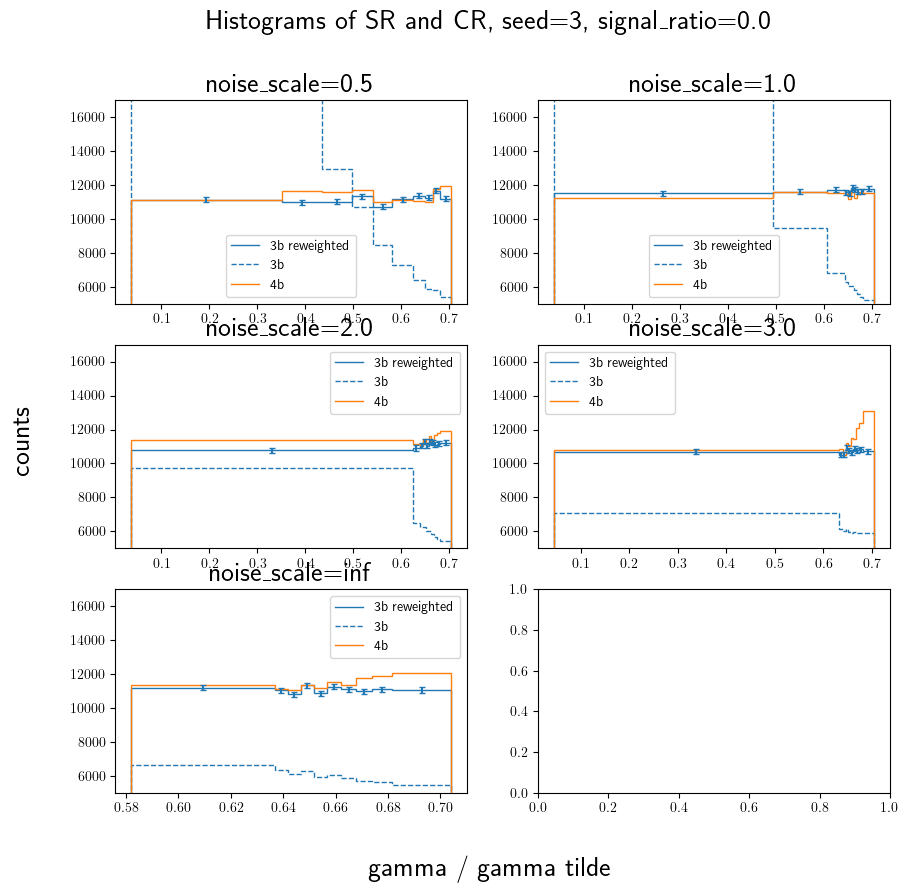

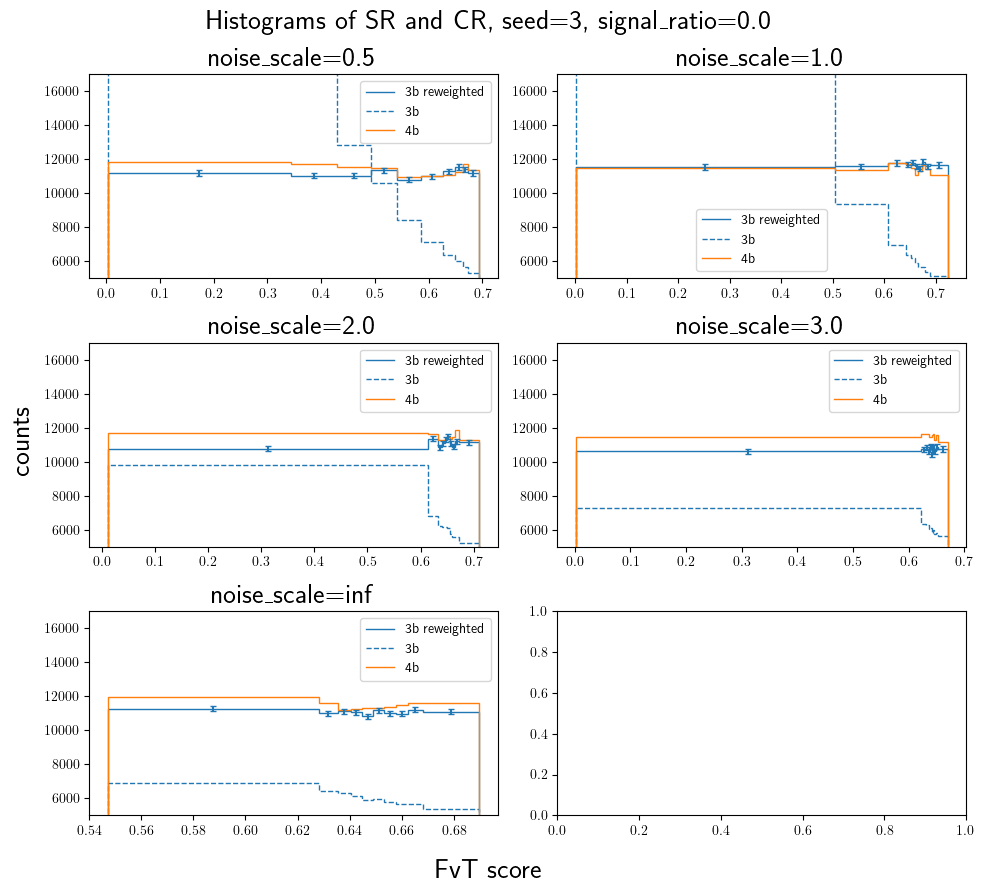

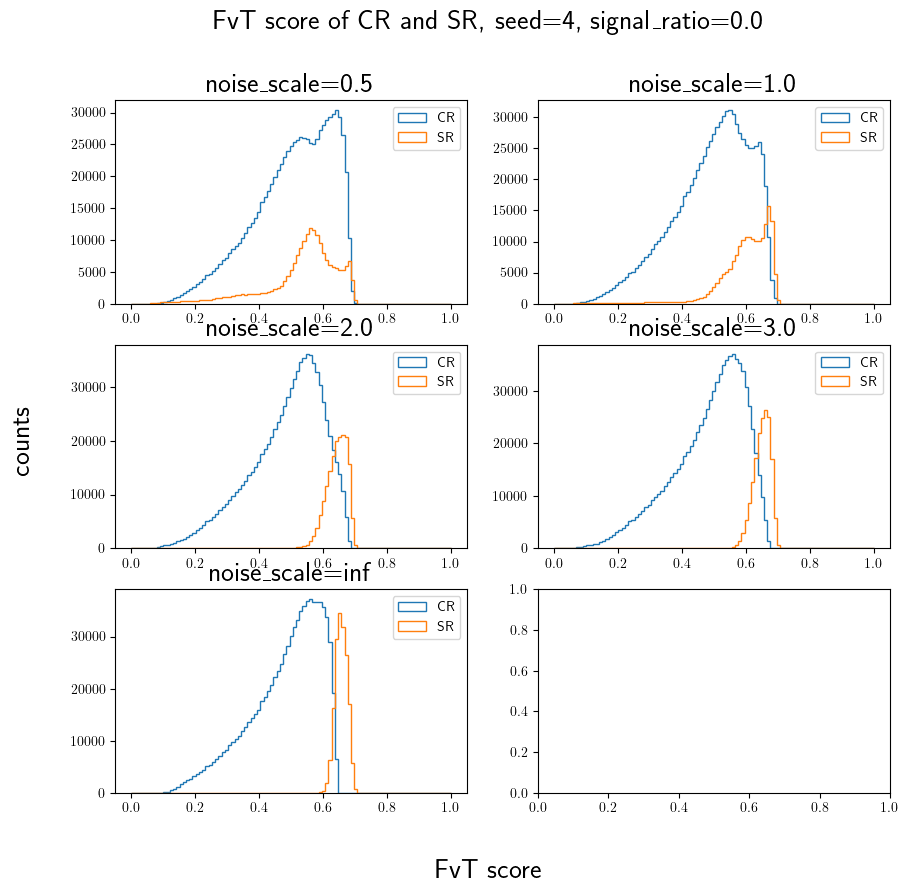

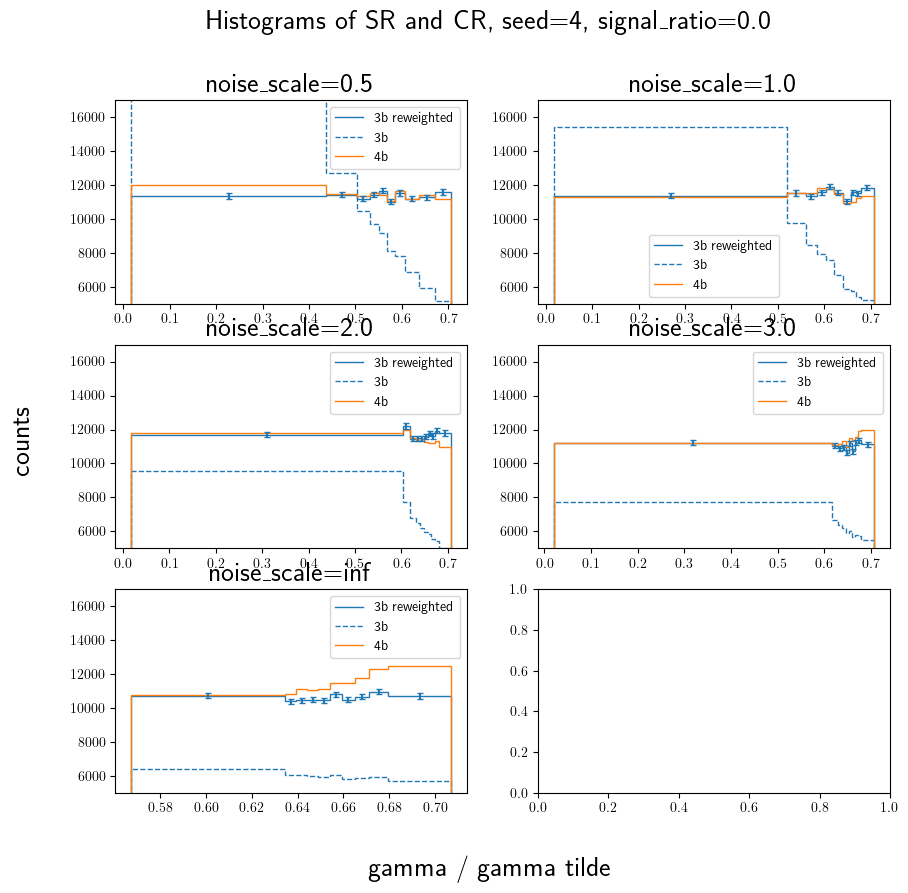

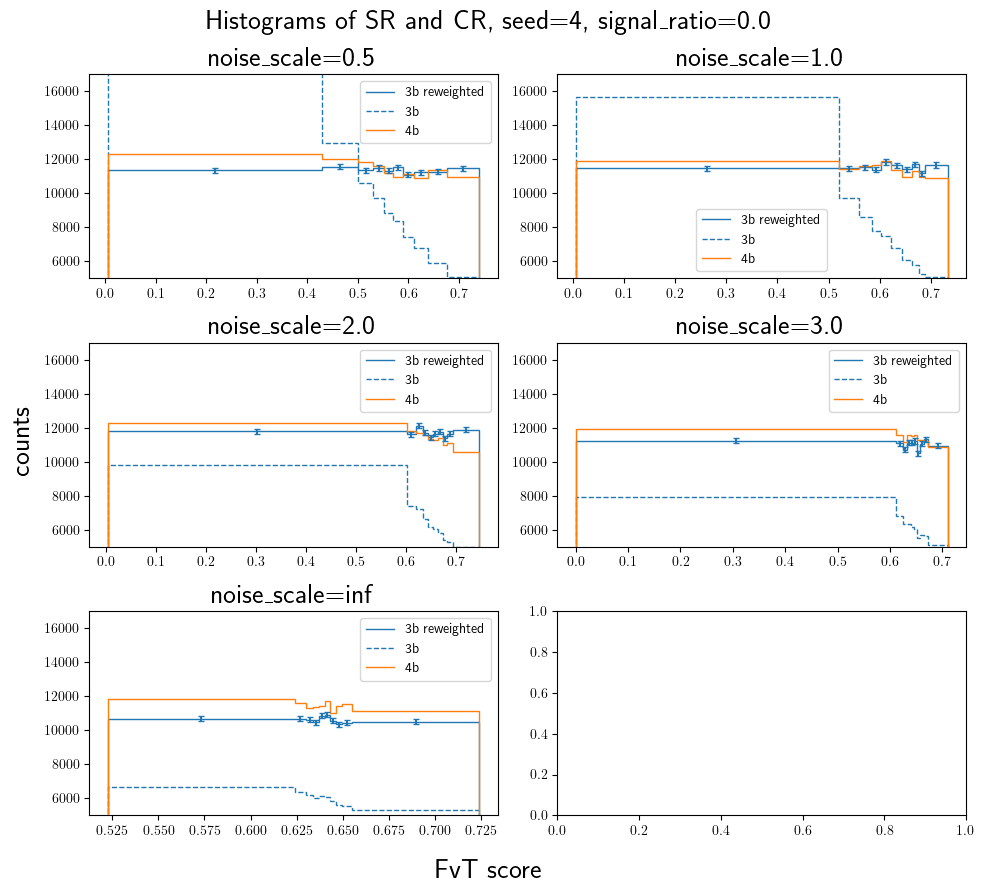

In [28]:
nbins = 10
signal_ratio = 0.0
signal_filename = "HH4b_picoAOD.h5"

for seed in [2, 3, 4]:
    hashes = TrainingInfo.find({"experiment_name": "CR_fvt_training_ensemble_max", 
                                    "dataset": lambda x: x["signal_ratio"] == signal_ratio and x["seed"] == seed, 
                                    "signal_region": lambda x: x["4b_in_SR"] == 0.2})

    noise_scales = []
    for hash_ in hashes:
        CR_fvt_tinfo = TrainingInfo.load(hash_)
        smeared_tinfo = TrainingInfo.load(CR_fvt_tinfo.hparams["signal_region"]["SR_stats_hashes"][0])
        if CR_fvt_tinfo.hparams["signal_region"]["stats_type"] == "smeared":
            noise_scale = smeared_tinfo.hparams["smearing"]["noise_scale"]
        else:
            noise_scale = np.inf
        noise_scales.append(noise_scale)
        
    # sort hashes by noise_scale 
    hashes = [x for _, x in sorted(zip(noise_scales, hashes), key=lambda pair: pair[0])]

    colors = plt.get_cmap("tab10")

    CR_fvt_tinfo = TrainingInfo.load(hashes[0])
    SR_stats_hashes = CR_fvt_tinfo.hparams["signal_region"]["SR_stats_hashes"]
    smeared_tinfo = TrainingInfo.load(SR_stats_hashes[0])
    msamples = MotherSamples.load(smeared_tinfo.ms_hash)
    events_train = events_from_scdinfo(
        msamples.scdinfo[smeared_tinfo.ms_idx], FEATURES, signal_filename
    )
    events_tst = events_from_scdinfo(
        msamples.scdinfo[~smeared_tinfo.ms_idx], FEATURES, signal_filename
    )

    base_fvt_scores_tst = []
    base_fvt_scores_train = []
    for hash_ in SR_stats_hashes:
        smeared_tinfo = TrainingInfo.load(hash_)
        base_tinfo = TrainingInfo.load(smeared_tinfo.hparams["encoder_hash"])
        base_fvt_logits_tst = base_tinfo.aux_info["base_fvt_logit_tst"]
        base_fvt_score_tst = np.exp(base_fvt_logits_tst) / (np.exp(base_fvt_logits_tst) + 1)
        base_fvt_scores_tst.append(base_fvt_score_tst)
        base_fvt_logits_train = base_tinfo.aux_info["base_fvt_logit_train"]
        base_fvt_score_train = np.exp(base_fvt_logits_train) / (np.exp(base_fvt_logits_train) + 1)
        base_fvt_scores_train.append(base_fvt_score_train)
        
    base_fvt_scores_tst = np.mean(base_fvt_scores_tst, axis=0)
    base_fvt_scores_train = np.mean(base_fvt_scores_train, axis=0)

    fig, axs = plt.subplots(nrows=3, ncols=2, figsize=(10, 9))
    fig.suptitle(f"FvT score of CR and SR, seed={seed}, signal_ratio={signal_ratio}")
    fig.supxlabel("FvT score")
    fig.supylabel("counts")

    fig_srs, axs_srs = plt.subplots(nrows=3, ncols=2, figsize=(10, 9))
    fig_srs.suptitle(f"Histograms of SR and CR, seed={seed}, signal_ratio={signal_ratio}")
    fig_srs.supxlabel("gamma / gamma tilde")
    fig_srs.supylabel("counts")

    fig_fvt, axs_fvt = plt.subplots(nrows=3, ncols=2, figsize=(10, 9))
    fig_fvt.suptitle(f"Histograms of SR and CR, seed={seed}, signal_ratio={signal_ratio}")
    fig_fvt.supxlabel("FvT score")
    fig_fvt.supylabel("counts")


    for i, hash_ in enumerate(hashes):
        ax = axs.flatten()[i]
        ax_srs = axs_srs.flatten()[i]
        ax_fvt = axs_fvt.flatten()[i]
        
        CR_fvt_tinfo = TrainingInfo.load(hash_)
        SR_stats_hashes = CR_fvt_tinfo.hparams["signal_region"]["SR_stats_hashes"]
        smeared_tinfo = TrainingInfo.load(SR_stats_hashes[0])
        
        if CR_fvt_tinfo.hparams["signal_region"]["stats_type"] == "smeared":
            noise_scale = smeared_tinfo.hparams["smearing"]["noise_scale"]
        else:
            noise_scale = np.inf
        ensemble_mode = CR_fvt_tinfo.hparams["signal_region"]["ensemble_mode"]
        stats_type = CR_fvt_tinfo.hparams["signal_region"]["stats_type"]

        SR_stats_train, SR_stats_tst = compute_sr_stats(
            SR_stats_hashes,
            signal_filename,
            ensemble_mode,
            stats_type,
        )
        
        SR_cut, CR_cut = get_SR_CR_cut(
            SR_stats_train, events_train, CR_fvt_tinfo.hparams["signal_region"]
        )
        CR_idx = (SR_stats_tst >= CR_cut) & (SR_stats_tst < SR_cut)
        SR_idx = SR_stats_tst >= SR_cut
        
        bins = np.linspace(0, 1, 100)
        ax.set_title(f"noise_scale={noise_scale}")
        ax.hist(base_fvt_score_tst[CR_idx], bins=bins, label="CR", histtype="step")
        ax.hist(base_fvt_score_tst[SR_idx], bins=bins, label="SR", histtype="step")
        ax.legend()
        
        events_train_SR = events_train[SR_stats_train >= SR_cut]
        SR_stats_train_SR = SR_stats_train[SR_stats_train >= SR_cut]
        events_tst_SR = events_tst[SR_stats_tst >= SR_cut]
        SR_stats_tst_SR = SR_stats_tst[SR_stats_tst >= SR_cut]
        base_fvt_scores_tst_SR = base_fvt_scores_tst[SR_stats_tst >= SR_cut]
        base_fvt_scores_train_SR = base_fvt_scores_train[SR_stats_train >= SR_cut]
        fvt_scores_train_SR = CR_fvt_tinfo.aux_info["fvt_scores_train_SR"]
        reweights_train_SR = fvt_scores_train_SR / (1 - fvt_scores_train_SR)
        fvt_scores_tst_SR = CR_fvt_tinfo.aux_info["fvt_scores_tst_SR"]
        reweights_SR = fvt_scores_tst_SR / (1 - fvt_scores_tst_SR)
        
        for mode in ["srs", "fvt"]:
            if mode == "fvt":
                hist_values_tst = base_fvt_scores_tst_SR
                hist_values_train = base_fvt_scores_train_SR
                current_ax = ax_srs
            else:
                hist_values_tst = fvt_scores_tst_SR
                hist_values_train = fvt_scores_train_SR
                current_ax = ax_fvt
                
            
            SR_bins = get_quantiles_with_weights(
                hist_values_train[events_train_SR.is_3b],
                (reweights_train_SR * events_train_SR.weights)[events_train_SR.is_3b],
                np.linspace(0, 1, nbins + 1),
            )
            
            
            hists = get_histograms(events_tst_SR, hist_values_tst, SR_bins, reweights_SR)
            error = np.sqrt(hists["3b_rw"] + hists["4b"])
            
            current_ax.set_title(f"noise_scale={noise_scale}")
            current_ax.stairs(hists["3b_rw"], SR_bins, label="3b reweighted", color=colors(0))
            current_ax.stairs(hists["3b"], SR_bins, label="3b", color=colors(0), linestyle="--")
            current_ax.stairs(hists["4b"], SR_bins, label="4b", color=colors(1))
            midpoints = (SR_bins[:-1] + SR_bins[1:]) / 2
            current_ax.errorbar(midpoints, hists["3b_rw"], error, color=colors(0), capsize=2, linestyle="")
            current_ax.legend()
            current_ax.set_ylim(5000, 17000)
            
    plt.tight_layout()
    plt.show()